# Predicción ligera de RUL mediante estadísticas temporales, MLP y MOPSO.
Este script propone una alternativa sencilla a los autoencoders, CNN, LSTM y
mecanismos de atención. En lugar de aplanar una ventana completa de sensores,
resume cada sensor mediante estadísticas temporales interpretables:
1. último valor
2. media
3. desviación estándar
4. pendiente lineal
5. diferencia entre el último y el primer valor

Con nueve sensores y cinco estadísticas, la entrada pasa de 270 variables
(30 ciclos x 9 sensores) a 45 variables. Después se busca automáticamente una
MLP ligera con una, dos o tres capas ocultas.

La búsqueda utiliza un PSO multiobjetivo (MOPSO) multifidelidad:

objetivo 1: minimizar el RMSE de validación.
objetivo 2: minimizar el número de parámetros.

No se suma una penalización fija al error. En su lugar, se conserva un frente
de Pareto con diferentes compromisos entre precisión y tamaño. Esto evita que
las redes grandes dominen la búsqueda solamente porque aprenden más rápido en
las primeras épocas.

## Características principales
1. Representación temporal estadística e interpretable.
2. Búsqueda de profundidad, anchuras, activación y dropout.
3. Restricción dura de parámetros para garantizar modelos ligeros.
4. PSO multiobjetivo con ordenamiento no dominado y crowding distance.
5. Enjambre decreciente y presupuestos crecientes de épocas.
6. Caché persistente y warm start por arquitectura.
7. Comparación justa: una arquitectura no recibe más épocas por repetirse.
8. Evaluación final con varias semillas y early stopping.
9. Selección automática de una solución de compromiso del frente de Pareto.
10. Evaluación coherente con RUL limitado a 125 y cálculo de NASA Score.

## Notas metodológicas
- Durante la búsqueda, el warm start conserva el último estado para continuar el entrenamiento, pero la puntuación utiliza el mejor checkpoint de validación observado hasta el presupuesto actual.
- En la evaluación final, todas las arquitecturas se entrenan desde cero con las mismas semillas. Esto evita favorecer a una arquitectura por haber sido visitada más veces durante la búsqueda.
- El conjunto de test no participa en la selección de arquitectura.

In [1]:
# Step 0: Install required packages in the Colab runtime.

!pip install numpy pandas scikit-learn matplotlib seaborn torch

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from __future__ import annotations

import copy
import hashlib
import json
import math
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

## 1. CONFIGURACIÓN GENERAL

In [23]:
# Carpeta que contiene train_FD001.txt, test_FD001.txt y RUL_FD001.txt.
DATA_DIR = Path("data/CMAPSSData")

# Para procesar todos los subconjuntos:
# DATASETS = ("FD001", "FD002", "FD003", "FD004")
DATASETS = ("FD001",)

# Longitud de la ventana temporal utilizada para crear cada ejemplo.
SEQ_LEN = 30

# Función RUL por tramos: todo valor superior se limita a 125.
RUL_MAX = 125

# Separación por motores, no por ventanas, para impedir fuga de información.
VALIDATION_SIZE = 0.20
RANDOM_STATE = 42

# Estadísticas que se calculan para cada sensor dentro de cada ventana.
# Se pueden eliminar o añadir en build_temporal_statistics().
TEMPORAL_STATISTICS = (
    "last",
    "mean",
    "std",
    "slope",
    "delta",
)

# Tamaños discretos que el MOPSO puede asignar a cada capa oculta.
# La búsqueda no necesita explorar todos los enteros entre 4 y 100.
WIDTH_CHOICES = (4, 8, 12, 16, 24, 32, 48, 64)

# Profundidad permitida para mantener una topología sencilla.
MIN_DEPTH = 1
MAX_DEPTH = 3

# Activaciones candidatas. Dropout no añade parámetros.
ACTIVATION_CHOICES = ("relu", "elu", "silu")
DROPOUT_CHOICES = (0.00, 0.05, 0.10, 0.20)

# Tamaño del enjambre en cada etapa. Se reduce de forma elitista mediante
# Pareto y crowding distance.
PARTICLE_SCHEDULE = (100, 50, 25, 12, 6, 4)

# Presupuesto total de entrenamiento de cada etapa. Una arquitectura que
# sobrevive continúa exactamente hasta el nuevo presupuesto mediante warm
# start. Todas las arquitecturas de una misma etapa tienen el mismo máximo.
SEARCH_TOTAL_EPOCHS = (100, 200, 400, 700, 1_000, 1_500)

# Cada cuántas épocas se mide la validación durante la búsqueda.
SEARCH_VALIDATION_INTERVAL = 25

# Restricción dura. Una arquitectura que exceda este valor no se entrena.
# Con aproximadamente 45 entradas, 10 000 parámetros permite redes bastante
# expresivas, pero mucho menores que el modelo previo de unas 29 000 unidades.
MAX_ALLOWED_PARAMETERS = 10_000

# Parámetros del PSO.
INERTIA_START = 0.80
INERTIA_END = 0.35
COGNITIVE_COEFFICIENT = 1.20
SOCIAL_COEFFICIENT = 1.80
INITIAL_MUTATION_PROBABILITY = 0.25
FINAL_MUTATION_PROBABILITY = 0.05

# Entrenamiento durante la búsqueda.
SEARCH_LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Evaluación final de alta fidelidad.
FINAL_CANDIDATE_COUNT = 6
FINAL_SEEDS = (11, 22, 33, 44, 55)
FINAL_MAX_EPOCHS = 5_000
FINAL_VALIDATION_INTERVAL = 25
FINAL_EARLY_STOPPING_PATIENCE = 30
FINAL_MIN_DELTA_RMSE = 0.01

# El early stopping se activa después de este mínimo de épocas para no detener
# prematuramente redes pequeñas que pueden aprender con mayor lentitud.
FINAL_MIN_EPOCHS_BEFORE_STOP = 500

# Dispositivo. En GPU, las matrices de este MLP son pequeñas, pero el
# entrenamiento de múltiples arquitecturas puede acelerarse.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Archivos de salida.
CACHE_VERSION = 4
CACHE_DIR = Path("mopso_cache")
RESULTS_DIR = Path("mopso_results")
MODELS_DIR = Path("mopso_models")

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 12, "figure.dpi": 180})


## 2. REPRODUCIBILIDAD Y UTILIDADES DE ESTADO

In [24]:
def set_global_seed(seed: int) -> None:
    """Configura NumPy y PyTorch para una ejecución reproducible."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # warn_only evita errores cuando una operación no tiene implementación
    # completamente determinista en una versión concreta de PyTorch.
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


@dataclass(frozen=True)
class Architecture:
    """Descripción discreta de una MLP candidata."""

    hidden_sizes: Tuple[int, ...]
    activation: str
    dropout: float

    def key(self) -> Tuple[Any, ...]:
        """Clave estable y serializable para caché y eliminación de duplicados."""
        return (
            tuple(int(value) for value in self.hidden_sizes),
            str(self.activation),
            round(float(self.dropout), 4),
        )

    def label(self) -> str:
        return (
            f"hidden={self.hidden_sizes}, activation={self.activation}, "
            f"dropout={self.dropout:.2f}"
        )


def stable_architecture_seed(base_seed: int, architecture: Architecture) -> int:
    """Genera una semilla estable sin depender de hash() de Python."""
    payload = json.dumps(
        {
            "base_seed": int(base_seed),
            "hidden_sizes": architecture.hidden_sizes,
            "activation": architecture.activation,
            "dropout": architecture.dropout,
        },
        sort_keys=True,
    ).encode("utf-8")

    digest = hashlib.sha256(payload).hexdigest()
    return int(digest[:8], 16) % 2_147_483_647


def move_nested_tensors_to_cpu(value: Any) -> Any:
    """Copia recursivamente tensores a CPU antes de guardarlos en disco."""
    if torch.is_tensor(value):
        return value.detach().cpu().clone()
    if isinstance(value, dict):
        return {
            key: move_nested_tensors_to_cpu(item)
            for key, item in value.items()
        }
    if isinstance(value, list):
        return [move_nested_tensors_to_cpu(item) for item in value]
    if isinstance(value, tuple):
        return tuple(move_nested_tensors_to_cpu(item) for item in value)
    return copy.deepcopy(value)


def move_optimizer_state_to_device(
    optimizer: optim.Optimizer,
    device: torch.device,
) -> None:
    """Mueve a GPU/CPU los tensores internos de un optimizador restaurado."""
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(device)

## 3. LECTURA Y PREPARACIÓN DE C-MAPSS

In [25]:
def load_cmapss(path: Path | str) -> pd.DataFrame:
    """Carga un archivo train/test de C-MAPSS."""
    column_names = [f"col_{index}" for index in range(1, 27)]
    return pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=column_names,
    )


def load_cmapss_rul(path: Path | str) -> pd.DataFrame:
    """Carga el RUL residual de cada motor del conjunto de test."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=["rul"],
    )


def compute_rul(
    dataframe: pd.DataFrame,
    base_rul: Optional[pd.Series] = None,
    clip_max: Optional[int] = RUL_MAX,
) -> pd.Series:
    """Calcula el RUL por fila.

    En entrenamiento, el último ciclo observado es el ciclo de fallo.
    En test, base_rul contiene los ciclos que quedan después del último ciclo
    observado. La salida se limita coherentemente a RUL_MAX.
    """
    maximum_cycle = dataframe.groupby("col_1")["col_2"].max()

    if base_rul is not None:
        base_rul = base_rul.copy()
        base_rul.index = base_rul.index.astype(maximum_cycle.index.dtype)
        maximum_cycle = maximum_cycle.add(base_rul, fill_value=np.nan)

    mapped_maximum = dataframe["col_1"].map(maximum_cycle)
    rul = mapped_maximum - dataframe["col_2"]
    rul = rul.clip(lower=0)

    if clip_max is not None:
        rul = rul.clip(upper=int(clip_max))

    return rul.astype(np.float32)


def select_non_flat_features(
    dataframe: pd.DataFrame,
    threshold: float = 1e-5,
) -> List[str]:
    """Elimina únicamente variables casi constantes en entrenamiento."""
    candidate_columns = list(dataframe.columns[2:])
    standard_deviations = dataframe[candidate_columns].std()
    selected = standard_deviations[
        standard_deviations > float(threshold)
    ].index.tolist()

    if not selected:
        raise ValueError("No quedaron variables C-MAPSS no constantes.")

    return selected


def build_temporal_statistics(
    window: np.ndarray,
    statistics: Sequence[str] = TEMPORAL_STATISTICS,
) -> np.ndarray:
    """Resume una ventana de forma interpretable.

    Parameters
    ----------
    window:
        Matriz de forma (n_ciclos, n_sensores), ya normalizada sensor a sensor.
    statistics:
        Estadísticas a concatenar. Cada una genera n_sensores variables.

    Returns
    -------
    np.ndarray
        Vector unidimensional de longitud n_sensores * n_estadísticas.
    """
    if window.ndim != 2:
        raise ValueError("window debe tener forma (ciclos, sensores).")

    n_cycles = window.shape[0]
    time_axis = np.arange(n_cycles, dtype=np.float32)
    centered_time = time_axis - time_axis.mean()
    slope_denominator = float(np.sum(centered_time**2))

    feature_blocks: List[np.ndarray] = []

    for statistic in statistics:
        if statistic == "last":
            values = window[-1]
        elif statistic == "mean":
            values = window.mean(axis=0)
        elif statistic == "std":
            values = window.std(axis=0, ddof=0)
        elif statistic == "slope":
            if slope_denominator == 0.0:
                values = np.zeros(window.shape[1], dtype=np.float32)
            else:
                values = (
                    centered_time[:, None] * window
                ).sum(axis=0) / slope_denominator
        elif statistic == "delta":
            values = window[-1] - window[0]
        elif statistic == "min":
            values = window.min(axis=0)
        elif statistic == "max":
            values = window.max(axis=0)
        else:
            raise ValueError(f"Estadística temporal no reconocida: {statistic}")

        feature_blocks.append(np.asarray(values, dtype=np.float32))

    return np.concatenate(feature_blocks).astype(np.float32)


def make_derived_feature_names(
    sensor_names: Sequence[str],
    statistics: Sequence[str] = TEMPORAL_STATISTICS,
) -> List[str]:
    """Nombres de las variables derivadas para trazabilidad."""
    return [
        f"{statistic}__{sensor}"
        for statistic in statistics
        for sensor in sensor_names
    ]


def build_statistical_windows(
    dataframe: pd.DataFrame,
    rul: pd.Series,
    seq_len: int,
    sensor_scaler: MinMaxScaler,
    statistics: Sequence[str] = TEMPORAL_STATISTICS,
    only_last: bool = False,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Construye ejemplos mediante estadísticas temporales por sensor.

    La normalización de sensores se realiza antes de calcular estadísticas.
    Después, las variables derivadas se estandarizan en una fase separada
    usando exclusivamente el conjunto de entrenamiento.
    """
    sensor_columns = list(dataframe.columns[2:])
    units = dataframe["col_1"].drop_duplicates().to_numpy()

    features: List[np.ndarray] = []
    targets: List[float] = []
    window_units: List[int] = []

    for unit in units:
        unit_dataframe = dataframe[dataframe["col_1"] == unit]
        unit_rul = rul.loc[unit_dataframe.index]

        scaled_sensors = sensor_scaler.transform(
            unit_dataframe[sensor_columns]
        ).astype(np.float32)

        if len(unit_dataframe) < seq_len:
            continue

        if only_last:
            starts = [len(unit_dataframe) - seq_len]
        else:
            starts = range(len(unit_dataframe) - seq_len + 1)

        for start in starts:
            end = start + seq_len
            window = scaled_sensors[start:end]
            derived = build_temporal_statistics(window, statistics)
            target = float(unit_rul.iloc[end - 1])

            features.append(derived)
            targets.append(target)
            window_units.append(int(unit))

    if not features:
        raise ValueError(
            "No se construyeron ventanas. Revise SEQ_LEN y los datos."
        )

    return (
        np.asarray(features, dtype=np.float32),
        np.asarray(targets, dtype=np.float32),
        np.asarray(window_units, dtype=np.int64),
    )

## 4. MLP CONFIGURABLE

In [26]:
def make_activation(name: str) -> nn.Module:
    """Crea una activación a partir del nombre almacenado en la arquitectura."""
    normalized = name.lower()
    if normalized == "relu":
        return nn.ReLU()
    if normalized == "elu":
        return nn.ELU(alpha=1.0)
    if normalized == "silu":
        return nn.SiLU()
    raise ValueError(f"Activación no soportada: {name}")


class TorchMLPRegressor(nn.Module):
    """MLP pequeña con profundidad, activación y dropout configurables."""

    def __init__(
        self,
        input_size: int,
        architecture: Architecture,
        output_size: int = 1,
    ) -> None:
        super().__init__()

        layers: List[nn.Module] = []
        in_features = int(input_size)

        for hidden_size in architecture.hidden_sizes:
            layers.append(nn.Linear(in_features, int(hidden_size)))
            layers.append(make_activation(architecture.activation))

            if architecture.dropout > 0.0:
                layers.append(nn.Dropout(p=float(architecture.dropout)))

            in_features = int(hidden_size)

        # Salida lineal. No se aplica clamp durante el entrenamiento para no
        # anular gradientes cuando la predicción inicial es negativa.
        layers.append(nn.Linear(in_features, int(output_size)))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


class MLPRegressor:
    """Envoltorio para entrenamiento, predicción y restauración de estados."""

    def __init__(
        self,
        input_size: int,
        architecture: Architecture,
        learning_rate: float = SEARCH_LEARNING_RATE,
        weight_decay: float = WEIGHT_DECAY,
        device: torch.device = DEVICE,
    ) -> None:
        self.input_size = int(input_size)
        self.architecture = architecture
        self.learning_rate = float(learning_rate)
        self.weight_decay = float(weight_decay)
        self.device = device

        self.model = TorchMLPRegressor(
            input_size=self.input_size,
            architecture=self.architecture,
        ).to(self.device)

        # SmoothL1 combina robustez frente a valores atípicos y gradientes
        # estables. reduction="mean" se usa para entrenamiento ordinario.
        self.criterion = nn.SmoothL1Loss(beta=1.0)

        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay,
        )

    def get_weights(self) -> Dict[str, torch.Tensor]:
        return move_nested_tensors_to_cpu(self.model.state_dict())

    def load_weights(self, state_dict: Dict[str, torch.Tensor]) -> None:
        self.model.load_state_dict(state_dict)
        self.model.to(self.device)

    def get_optimizer_state(self) -> Dict[str, Any]:
        return move_nested_tensors_to_cpu(self.optimizer.state_dict())

    def load_optimizer_state(self, state_dict: Dict[str, Any]) -> None:
        self.optimizer.load_state_dict(state_dict)
        move_optimizer_state_to_device(self.optimizer, self.device)

    def predict_raw(self, X: np.ndarray) -> np.ndarray:
        X_tensor = torch.as_tensor(
            X,
            dtype=torch.float32,
            device=self.device,
        )
        self.model.eval()

        with torch.no_grad():
            predictions = self.model(X_tensor)

        return predictions.detach().cpu().numpy().reshape(-1)

    def predict_clipped(self, X: np.ndarray) -> np.ndarray:
        return np.clip(self.predict_raw(X), 0.0, float(RUL_MAX))

## 5. MÉTRICAS Y COMPLEJIDAD

In [27]:
def regression_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> Dict[str, float]:
    mse = float(mean_squared_error(y_true, y_pred))
    return {
        "mse": mse,
        "rmse": float(math.sqrt(mse)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
    }


def nasa_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calcula el NASA Score habitual para C-MAPSS.

    Los errores positivos corresponden a sobreestimación del RUL y reciben
    una penalización más rápida, porque pueden retrasar una intervención.
    """
    errors = np.asarray(y_pred) - np.asarray(y_true)
    errors = np.clip(errors, -200.0, 200.0)

    penalties = np.where(
        errors < 0,
        np.exp(-errors / 13.0) - 1.0,
        np.exp(errors / 10.0) - 1.0,
    )
    return float(np.sum(penalties))


def count_mlp_parameters(
    input_size: int,
    architecture: Architecture,
    output_size: int = 1,
) -> int:
    """Cuenta pesos y sesgos; dropout y activaciones no añaden parámetros."""
    layer_sizes = (
        int(input_size),
        *(int(value) for value in architecture.hidden_sizes),
        int(output_size),
    )

    return int(
        sum(
            (in_features + 1) * out_features
            for in_features, out_features in zip(
                layer_sizes[:-1],
                layer_sizes[1:],
            )
        )
    )

## 6. ENTRENAMIENTO CON CHECKPOINT DE VALIDACIÓN

In [28]:
@dataclass
class TrainingState:
    """Estado de continuación y mejor checkpoint observado."""

    total_epochs: int
    resume_weights: Dict[str, torch.Tensor]
    optimizer_state: Dict[str, Any]
    best_weights: Dict[str, torch.Tensor]
    best_epoch: int
    best_metrics: Dict[str, float]
    final_training_loss: float


def train_additional_epochs(
    model: MLPRegressor,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    start_epoch: int,
    additional_epochs: int,
    validation_interval: int,
    previous_best_weights: Optional[Dict[str, torch.Tensor]] = None,
    previous_best_epoch: int = 0,
    previous_best_metrics: Optional[Dict[str, float]] = None,
    early_stopping_patience: Optional[int] = None,
    minimum_epochs_before_stop: int = 0,
    minimum_delta_rmse: float = 0.0,
    verbose: bool = False,
) -> TrainingState:
    """Continúa el entrenamiento y conserva dos estados diferentes.

    resume_weights:
        Pesos de la última época. Se utilizan para continuar el entrenamiento.

    best_weights:
        Pesos de la época con menor RMSE de validación. Se utilizan para medir
        la calidad y para devolver el modelo final.

    Separar ambos estados evita que el early stopping o el mejor checkpoint
    rompan la trayectoria del optimizador utilizada por el warm start.
    """
    if additional_epochs < 0:
        raise ValueError("additional_epochs no puede ser negativo.")
    if validation_interval < 1:
        raise ValueError("validation_interval debe ser positivo.")

    X_train_tensor = torch.as_tensor(
        X_train,
        dtype=torch.float32,
        device=model.device,
    )
    y_train_tensor = torch.as_tensor(
        y_train,
        dtype=torch.float32,
        device=model.device,
    ).reshape(-1, 1)

    if previous_best_metrics is None:
        best_rmse = float("inf")
        best_metrics = {
            "mse": float("inf"),
            "rmse": float("inf"),
            "mae": float("inf"),
        }
        best_weights = model.get_weights()
        best_epoch = int(start_epoch)
    else:
        best_rmse = float(previous_best_metrics["rmse"])
        best_metrics = copy.deepcopy(previous_best_metrics)
        best_weights = (
            model.get_weights()
            if previous_best_weights is None
            else copy.deepcopy(previous_best_weights)
        )
        best_epoch = int(previous_best_epoch)

    checks_without_improvement = 0
    final_loss = float("nan")
    actual_additional_epochs = 0

    start_time = time.time()

    for local_epoch in range(1, additional_epochs + 1):
        global_epoch = int(start_epoch + local_epoch)
        actual_additional_epochs = local_epoch

        model.model.train()
        model.optimizer.zero_grad(set_to_none=True)

        predictions = model.model(X_train_tensor)
        loss = model.criterion(predictions, y_train_tensor)
        loss.backward()
        model.optimizer.step()
        final_loss = float(loss.item())

        must_validate = (
            local_epoch % validation_interval == 0
            or local_epoch == additional_epochs
        )

        if must_validate:
            validation_predictions = model.predict_clipped(X_val)
            metrics = regression_metrics(y_val, validation_predictions)

            improvement = best_rmse - metrics["rmse"]
            if improvement > float(minimum_delta_rmse):
                best_rmse = float(metrics["rmse"])
                best_metrics = metrics
                best_weights = model.get_weights()
                best_epoch = global_epoch
                checks_without_improvement = 0
            else:
                checks_without_improvement += 1

            if verbose:
                print(
                    f"      Época {global_epoch} | "
                    f"Loss={final_loss:.4f} | "
                    f"Val RMSE={metrics['rmse']:.4f} | "
                    f"Mejor RMSE={best_rmse:.4f} en época {best_epoch}"
                )

            can_stop = (
                early_stopping_patience is not None
                and global_epoch >= minimum_epochs_before_stop
                and checks_without_improvement >= early_stopping_patience
            )
            if can_stop:
                if verbose:
                    print(
                        "      Early stopping: no hubo mejora suficiente "
                        f"durante {checks_without_improvement} controles."
                    )
                break

    elapsed = time.time() - start_time
    total_epochs = int(start_epoch + actual_additional_epochs)

    if verbose:
        print(
            f"    Entrenamiento terminado en {elapsed:.2f}s | "
            f"épocas totales={total_epochs} | mejor época={best_epoch}"
        )

    return TrainingState(
        total_epochs=total_epochs,
        resume_weights=model.get_weights(),
        optimizer_state=model.get_optimizer_state(),
        best_weights=best_weights,
        best_epoch=best_epoch,
        best_metrics=best_metrics,
        final_training_loss=final_loss,
    )

## 7. CACHÉ DE ARQUITECTURAS PARA WARM START

In [29]:
ArchitectureCache = Dict[Tuple[Any, ...], Dict[str, Any]]


def load_search_cache(
    path: Optional[Path],
    cache_id: str,
    input_size: int,
) -> ArchitectureCache:
    """Carga únicamente cachés compatibles con datos y configuración."""
    if path is None or not path.exists():
        return {}

    try:
        try:
            package = torch.load(
                path,
                map_location="cpu",
                weights_only=False,
            )
        except TypeError:
            package = torch.load(path, map_location="cpu")
    except Exception as exc:
        print(f"Aviso: no se pudo cargar la caché {path}: {exc}")
        return {}

    if package.get("version") != CACHE_VERSION:
        print("Aviso: se ignoró una caché de otra versión.")
        return {}
    if package.get("cache_id") != cache_id:
        print("Aviso: la caché pertenece a otra preparación de datos.")
        return {}
    if int(package.get("input_size", -1)) != int(input_size):
        print("Aviso: la caché tiene otro tamaño de entrada.")
        return {}

    entries = package.get("entries", {})
    print(f"Caché cargada: {len(entries)} arquitecturas desde {path}.")
    return entries


def save_search_cache(
    path: Optional[Path],
    cache: ArchitectureCache,
    cache_id: str,
    input_size: int,
) -> None:
    """Guarda la caché mediante reemplazo atómico."""
    if path is None:
        return

    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_suffix(path.suffix + ".tmp")

    torch.save(
        {
            "version": CACHE_VERSION,
            "cache_id": cache_id,
            "input_size": int(input_size),
            "entries": cache,
        },
        temporary_path,
    )
    temporary_path.replace(path)


def get_snapshot_at_or_below(
    entry: Dict[str, Any],
    target_epochs: int,
) -> Tuple[int, Optional[Dict[str, Any]]]:
    snapshots = entry.get("snapshots", {})
    eligible = [
        int(epoch)
        for epoch in snapshots
        if int(epoch) <= int(target_epochs)
    ]

    if not eligible:
        return 0, None

    selected_epoch = max(eligible)
    return selected_epoch, snapshots[selected_epoch]


@dataclass
class SearchEvaluation:
    architecture: Architecture
    rmse: float
    mse: float
    mae: float
    n_parameters: int
    best_epoch: int
    total_epochs: int
    trained_now: int
    status: str
    optimizer_restored: bool
    feasible: bool
    elapsed: float


def evaluate_architecture_with_cache(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    architecture: Architecture,
    target_total_epochs: int,
    cache: ArchitectureCache,
    input_size: int,
    base_seed: int,
) -> SearchEvaluation:
    """Evalúa una arquitectura con warm start y presupuesto total exacto."""
    start_time = time.time()
    n_parameters = count_mlp_parameters(input_size, architecture)

    if n_parameters > MAX_ALLOWED_PARAMETERS:
        return SearchEvaluation(
            architecture=architecture,
            rmse=float("inf"),
            mse=float("inf"),
            mae=float("inf"),
            n_parameters=n_parameters,
            best_epoch=0,
            total_epochs=0,
            trained_now=0,
            status="inviable-por-parámetros",
            optimizer_restored=False,
            feasible=False,
            elapsed=time.time() - start_time,
        )

    cache_key = architecture.key()
    entry = cache.setdefault(
        cache_key,
        {
            "architecture": architecture,
            "snapshots": {},
            "evaluations": 0,
        },
    )

    target_total_epochs = int(target_total_epochs)
    snapshots = entry.setdefault("snapshots", {})
    exact_hit = target_total_epochs in snapshots
    start_epoch, snapshot = get_snapshot_at_or_below(
        entry,
        target_total_epochs,
    )

    seed = stable_architecture_seed(base_seed, architecture)
    set_global_seed(seed)

    model = MLPRegressor(
        input_size=input_size,
        architecture=architecture,
        learning_rate=SEARCH_LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    optimizer_restored = False
    previous_best_weights = None
    previous_best_metrics = None
    previous_best_epoch = 0

    if snapshot is not None:
        model.load_weights(snapshot["resume_weights"])
        previous_best_weights = snapshot["best_weights"]
        previous_best_metrics = snapshot["best_metrics"]
        previous_best_epoch = int(snapshot["best_epoch"])

        try:
            model.load_optimizer_state(snapshot["optimizer_state"])
            optimizer_restored = True
        except (ValueError, RuntimeError, KeyError) as exc:
            print(
                f"Aviso: no se restauró AdamW para {architecture.label()}: "
                f"{exc}. Se conservaron los pesos."
            )

    additional_epochs = target_total_epochs - start_epoch

    if exact_hit and additional_epochs == 0:
        exact_snapshot = snapshots[target_total_epochs]
        metrics = exact_snapshot["best_metrics"]
        best_epoch = int(exact_snapshot["best_epoch"])
        total_epochs = target_total_epochs
        status = "cache-exacta"
    else:
        training_state = train_additional_epochs(
            model=model,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            start_epoch=start_epoch,
            additional_epochs=additional_epochs,
            validation_interval=SEARCH_VALIDATION_INTERVAL,
            previous_best_weights=previous_best_weights,
            previous_best_epoch=previous_best_epoch,
            previous_best_metrics=previous_best_metrics,
            early_stopping_patience=None,
            minimum_delta_rmse=0.0,
            verbose=False,
        )

        snapshots[target_total_epochs] = {
            "resume_weights": training_state.resume_weights,
            "optimizer_state": training_state.optimizer_state,
            "best_weights": training_state.best_weights,
            "best_epoch": training_state.best_epoch,
            "best_metrics": training_state.best_metrics,
            "final_training_loss": training_state.final_training_loss,
            "seed": seed,
        }

        metrics = training_state.best_metrics
        best_epoch = training_state.best_epoch
        total_epochs = target_total_epochs
        status = "warm" if start_epoch > 0 else "cold"

    entry["evaluations"] = int(entry.get("evaluations", 0)) + 1

    return SearchEvaluation(
        architecture=architecture,
        rmse=float(metrics["rmse"]),
        mse=float(metrics["mse"]),
        mae=float(metrics["mae"]),
        n_parameters=n_parameters,
        best_epoch=best_epoch,
        total_epochs=total_epochs,
        trained_now=max(0, additional_epochs),
        status=status,
        optimizer_restored=optimizer_restored,
        feasible=True,
        elapsed=time.time() - start_time,
    )

## 8. ESPACIO DE BÚSQUEDA DISCRETO

In [30]:
class SearchSpace:
    """Codificación continua del PSO y decodificación a una arquitectura."""

    def __init__(self) -> None:
        # Posición:
        # [profundidad, ancho1, ancho2, ancho3, activación, dropout]
        self.dimension = 1 + MAX_DEPTH + 2

        self.lower_bounds = np.asarray(
            [
                MIN_DEPTH,
                *([0] * MAX_DEPTH),
                0,
                0,
            ],
            dtype=np.float64,
        )
        self.upper_bounds = np.asarray(
            [
                MAX_DEPTH,
                *([len(WIDTH_CHOICES) - 1] * MAX_DEPTH),
                len(ACTIVATION_CHOICES) - 1,
                len(DROPOUT_CHOICES) - 1,
            ],
            dtype=np.float64,
        )

    def random_position(self, rng: np.random.Generator) -> np.ndarray:
        return rng.uniform(self.lower_bounds, self.upper_bounds)

    def clip(self, position: np.ndarray) -> np.ndarray:
        return np.clip(position, self.lower_bounds, self.upper_bounds)

    def decode(self, position: np.ndarray) -> Architecture:
        clipped = self.clip(position)

        depth = int(round(clipped[0]))
        depth = int(np.clip(depth, MIN_DEPTH, MAX_DEPTH))

        width_indices = [
            int(np.clip(round(value), 0, len(WIDTH_CHOICES) - 1))
            for value in clipped[1 : 1 + MAX_DEPTH]
        ]
        hidden_sizes = tuple(
            int(WIDTH_CHOICES[index])
            for index in width_indices[:depth]
        )

        activation_index = int(
            np.clip(
                round(clipped[1 + MAX_DEPTH]),
                0,
                len(ACTIVATION_CHOICES) - 1,
            )
        )
        dropout_index = int(
            np.clip(
                round(clipped[2 + MAX_DEPTH]),
                0,
                len(DROPOUT_CHOICES) - 1,
            )
        )

        return Architecture(
            hidden_sizes=hidden_sizes,
            activation=ACTIVATION_CHOICES[activation_index],
            dropout=float(DROPOUT_CHOICES[dropout_index]),
        )


## 9. OPERADORES MULTIOBJETIVO: PARETO Y CROWDING DISTANCE

In [31]:
@dataclass
class Particle:
    position: np.ndarray
    velocity: np.ndarray
    memory_position: np.ndarray
    last_evaluation: Optional[SearchEvaluation] = None


@dataclass
class ParetoRecord:
    particle: Particle
    evaluation: SearchEvaluation
    rank: int = 0
    crowding_distance: float = 0.0

    @property
    def objectives(self) -> Tuple[float, float]:
        return (
            float(self.evaluation.rmse),
            float(self.evaluation.n_parameters),
        )


def dominates(first: ParetoRecord, second: ParetoRecord) -> bool:
    """Verdadero si first no es peor en nada y mejora al menos un objetivo."""
    first_objectives = first.objectives
    second_objectives = second.objectives

    no_worse = all(
        first_value <= second_value
        for first_value, second_value in zip(
            first_objectives,
            second_objectives,
        )
    )
    strictly_better = any(
        first_value < second_value
        for first_value, second_value in zip(
            first_objectives,
            second_objectives,
        )
    )
    return no_worse and strictly_better


def fast_non_dominated_sort(
    records: Sequence[ParetoRecord],
) -> List[List[ParetoRecord]]:
    """Ordenamiento no dominado tipo NSGA-II para una población pequeña."""
    if not records:
        return []

    domination_sets: Dict[int, List[int]] = {
        index: [] for index in range(len(records))
    }
    dominated_counts = np.zeros(len(records), dtype=int)
    fronts_indices: List[List[int]] = [[]]

    for first_index, first in enumerate(records):
        for second_index, second in enumerate(records):
            if first_index == second_index:
                continue

            if dominates(first, second):
                domination_sets[first_index].append(second_index)
            elif dominates(second, first):
                dominated_counts[first_index] += 1

        if dominated_counts[first_index] == 0:
            records[first_index].rank = 0
            fronts_indices[0].append(first_index)

    current_front = 0
    while current_front < len(fronts_indices):
        next_front: List[int] = []

        for first_index in fronts_indices[current_front]:
            for dominated_index in domination_sets[first_index]:
                dominated_counts[dominated_index] -= 1
                if dominated_counts[dominated_index] == 0:
                    records[dominated_index].rank = current_front + 1
                    next_front.append(dominated_index)

        if next_front:
            fronts_indices.append(next_front)
        current_front += 1

    return [
        [records[index] for index in front]
        for front in fronts_indices
        if front
    ]


def assign_crowding_distance(front: Sequence[ParetoRecord]) -> None:
    """Asigna mayor distancia a soluciones aisladas y a extremos del frente."""
    if not front:
        return

    for record in front:
        record.crowding_distance = 0.0

    if len(front) <= 2:
        for record in front:
            record.crowding_distance = float("inf")
        return

    objective_count = 2

    for objective_index in range(objective_count):
        ordered = sorted(
            front,
            key=lambda record: record.objectives[objective_index],
        )

        ordered[0].crowding_distance = float("inf")
        ordered[-1].crowding_distance = float("inf")

        minimum = ordered[0].objectives[objective_index]
        maximum = ordered[-1].objectives[objective_index]
        denominator = maximum - minimum

        if denominator == 0:
            continue

        for index in range(1, len(ordered) - 1):
            previous_value = ordered[index - 1].objectives[objective_index]
            next_value = ordered[index + 1].objectives[objective_index]

            if not math.isinf(ordered[index].crowding_distance):
                ordered[index].crowding_distance += (
                    next_value - previous_value
                ) / denominator


def rank_population(
    records: Sequence[ParetoRecord],
) -> List[List[ParetoRecord]]:
    fronts = fast_non_dominated_sort(records)
    for front in fronts:
        assign_crowding_distance(front)
    return fronts


def select_survivors(
    records: Sequence[ParetoRecord],
    target_count: int,
) -> List[ParetoRecord]:
    """Selecciona por rango Pareto y diversidad, no por una suma ponderada."""
    fronts = rank_population(records)
    selected: List[ParetoRecord] = []

    for front in fronts:
        if len(selected) + len(front) <= target_count:
            selected.extend(front)
            continue

        remaining = target_count - len(selected)
        ordered = sorted(
            front,
            key=lambda record: record.crowding_distance,
            reverse=True,
        )
        selected.extend(ordered[:remaining])
        break

    return selected


def pareto_front(records: Sequence[ParetoRecord]) -> List[ParetoRecord]:
    fronts = rank_population(records)
    return fronts[0] if fronts else []


def choose_guide(
    archive: Sequence[ParetoRecord],
    rng: np.random.Generator,
) -> ParetoRecord:
    """Elige una guía favoreciendo regiones poco pobladas del frente."""
    if not archive:
        raise ValueError("El archivo Pareto no puede estar vacío.")

    finite_distances = [
        record.crowding_distance
        for record in archive
        if math.isfinite(record.crowding_distance)
    ]
    reference = max(finite_distances, default=1.0)

    weights = np.asarray(
        [
            2.0 * reference
            if math.isinf(record.crowding_distance)
            else max(record.crowding_distance, 1e-6)
            for record in archive
        ],
        dtype=np.float64,
    )
    probabilities = weights / weights.sum()
    index = int(rng.choice(len(archive), p=probabilities))
    return archive[index]


def compromise_record(
    archive: Sequence[ParetoRecord],
) -> ParetoRecord:
    """Selecciona el punto más cercano a la utopía normalizada (0, 0)."""
    if not archive:
        raise ValueError("El archivo Pareto no puede estar vacío.")

    rmses = np.asarray(
        [record.evaluation.rmse for record in archive],
        dtype=np.float64,
    )
    parameters = np.asarray(
        [record.evaluation.n_parameters for record in archive],
        dtype=np.float64,
    )

    rmse_range = max(float(rmses.max() - rmses.min()), 1e-12)
    parameter_range = max(
        float(parameters.max() - parameters.min()),
        1e-12,
    )

    normalized_rmse = (rmses - rmses.min()) / rmse_range
    normalized_parameters = (
        parameters - parameters.min()
    ) / parameter_range

    distances = np.sqrt(normalized_rmse**2 + normalized_parameters**2)
    return archive[int(np.argmin(distances))]

## 10. MOPSO MULTIFIDELIDAD

In [32]:
@dataclass
class MOPSOResult:
    final_pareto: List[ParetoRecord]
    selected_candidates: List[Architecture]
    stage_history: pd.DataFrame
    all_evaluations: pd.DataFrame


def ensure_unique_architecture(
    particle: Particle,
    search_space: SearchSpace,
    seen: set[Tuple[Any, ...]],
    rng: np.random.Generator,
    max_attempts: int = 100,
) -> Tuple[Architecture, bool]:
    """Reubica discretamente una partícula si repite arquitectura en la etapa."""
    architecture = search_space.decode(particle.position)
    if architecture.key() not in seen:
        return architecture, False

    original_position = particle.position.copy()

    for attempt in range(1, max_attempts + 1):
        scale = 0.20 + 0.04 * attempt
        candidate = search_space.clip(
            original_position
            + rng.normal(0.0, scale, size=search_space.dimension)
        )
        architecture = search_space.decode(candidate)

        if architecture.key() not in seen:
            particle.position = candidate
            return architecture, True

    for _ in range(max_attempts):
        candidate = search_space.random_position(rng)
        architecture = search_space.decode(candidate)
        if architecture.key() not in seen:
            particle.position = candidate
            return architecture, True

    return search_space.decode(original_position), False


def choose_final_candidates(
    archive: Sequence[ParetoRecord],
    candidate_count: int,
) -> List[Architecture]:
    """Extrae puntos representativos del frente final.

    Siempre incluye:
    - mejor RMSE;
    - menor número de parámetros;
    - punto de compromiso normalizado.

    Las plazas restantes se completan por crowding distance para mantener
    diversidad de tamaños.
    """
    if not archive:
        raise ValueError("No existe frente Pareto final.")

    assign_crowding_distance(archive)

    best_rmse = min(archive, key=lambda record: record.evaluation.rmse)
    smallest = min(
        archive,
        key=lambda record: record.evaluation.n_parameters,
    )
    compromise = compromise_record(archive)

    ordered_candidates = [best_rmse, smallest, compromise]
    ordered_candidates.extend(
        sorted(
            archive,
            key=lambda record: record.crowding_distance,
            reverse=True,
        )
    )

    selected: List[Architecture] = []
    seen: set[Tuple[Any, ...]] = set()

    for record in ordered_candidates:
        architecture = record.evaluation.architecture
        if architecture.key() in seen:
            continue

        selected.append(architecture)
        seen.add(architecture.key())

        if len(selected) == min(candidate_count, len(archive)):
            break

    return selected


def run_mopso(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    cache_path: Optional[Path],
    cache_id: str,
    random_state: int = RANDOM_STATE,
) -> MOPSOResult:
    """Ejecuta MOPSO con reducción del enjambre y fidelidad creciente."""
    if len(PARTICLE_SCHEDULE) != len(SEARCH_TOTAL_EPOCHS):
        raise ValueError(
            "PARTICLE_SCHEDULE y SEARCH_TOTAL_EPOCHS deben tener igual longitud."
        )

    if any(
        following >= current
        for current, following in zip(
            PARTICLE_SCHEDULE,
            PARTICLE_SCHEDULE[1:],
        )
    ):
        raise ValueError("PARTICLE_SCHEDULE debe ser estrictamente decreciente.")

    search_space = SearchSpace()
    rng = np.random.default_rng(random_state)
    set_global_seed(random_state)

    particles: List[Particle] = []
    for _ in range(PARTICLE_SCHEDULE[0]):
        position = search_space.random_position(rng)
        particles.append(
            Particle(
                position=position,
                velocity=np.zeros(search_space.dimension, dtype=np.float64),
                memory_position=position.copy(),
            )
        )

    cache = load_search_cache(
        path=cache_path,
        cache_id=cache_id,
        input_size=X_train.shape[1],
    )

    previous_archive: List[ParetoRecord] = []
    stage_rows: List[Dict[str, Any]] = []
    evaluation_rows: List[Dict[str, Any]] = []

    optimization_start = time.time()

    for stage_index, (
        particle_count,
        target_epochs,
    ) in enumerate(zip(PARTICLE_SCHEDULE, SEARCH_TOTAL_EPOCHS)):
        stage_start = time.time()

        # Al comienzo de una nueva etapa, la población ya fue reducida al
        # tamaño correspondiente. Después se desplazan las partículas usando
        # guías del frente Pareto anterior.
        if stage_index > 0:
            progress = stage_index / max(len(PARTICLE_SCHEDULE) - 1, 1)
            inertia = (
                INERTIA_START
                + progress * (INERTIA_END - INERTIA_START)
            )
            mutation_probability = (
                INITIAL_MUTATION_PROBABILITY
                + progress
                * (
                    FINAL_MUTATION_PROBABILITY
                    - INITIAL_MUTATION_PROBABILITY
                )
            )

            for particle_index, particle in enumerate(particles):
                # La primera partícula se mantiene como élite sin mover para
                # asegurar continuidad de al menos una solución del frente.
                if particle_index == 0 or not previous_archive:
                    continue

                guide = choose_guide(previous_archive, rng)
                r1 = rng.random(search_space.dimension)
                r2 = rng.random(search_space.dimension)

                particle.velocity = (
                    inertia * particle.velocity
                    + COGNITIVE_COEFFICIENT
                    * r1
                    * (particle.memory_position - particle.position)
                    + SOCIAL_COEFFICIENT
                    * r2
                    * (guide.particle.position - particle.position)
                )

                particle.position = search_space.clip(
                    particle.position + particle.velocity
                )

                # Mutación decreciente para evitar convergencia prematura.
                if rng.random() < mutation_probability:
                    mutation = rng.normal(
                        loc=0.0,
                        scale=0.50 * (1.0 - 0.60 * progress),
                        size=search_space.dimension,
                    )
                    particle.position = search_space.clip(
                        particle.position + mutation
                    )

        print(
            f"\n--- MOPSO Etapa {stage_index + 1}/{len(PARTICLE_SCHEDULE)} | "
            f"partículas={len(particles)} | "
            f"presupuesto total={target_epochs} épocas ---"
        )

        stage_records: List[ParetoRecord] = []
        seen_architectures: set[Tuple[Any, ...]] = set()
        stage_results: Dict[Tuple[Any, ...], SearchEvaluation] = {}

        for particle_index, particle in enumerate(particles, start=1):
            architecture, relocated = ensure_unique_architecture(
                particle=particle,
                search_space=search_space,
                seen=seen_architectures,
                rng=rng,
            )
            key = architecture.key()
            seen_architectures.add(key)

            # Esta protección impide entrenar dos veces la misma arquitectura
            # si el espacio discreto se saturara y la reubicación no funcionara.
            if key in stage_results:
                evaluation = copy.deepcopy(stage_results[key])
                evaluation.status = "duplicada-reutilizada"
                evaluation.trained_now = 0
            else:
                evaluation = evaluate_architecture_with_cache(
                    X_train=X_train,
                    y_train=y_train,
                    X_val=X_val,
                    y_val=y_val,
                    architecture=architecture,
                    target_total_epochs=target_epochs,
                    cache=cache,
                    input_size=X_train.shape[1],
                    base_seed=random_state,
                )
                stage_results[key] = copy.deepcopy(evaluation)

            particle.last_evaluation = evaluation
            particle.memory_position = particle.position.copy()

            record = ParetoRecord(
                particle=particle,
                evaluation=evaluation,
            )
            stage_records.append(record)

            relocation_text = ", reubicada" if relocated else ""
            optimizer_text = (
                ", AdamW restaurado"
                if evaluation.optimizer_restored
                else ""
            )

            print(
                f"  [{particle_index}/{len(particles)}] "
                f"{architecture.label()} | "
                f"RMSE={evaluation.rmse:.3f} | "
                f"MAE={evaluation.mae:.3f} | "
                f"Params={evaluation.n_parameters:,} | "
                f"{evaluation.status}{optimizer_text}{relocation_text} | "
                f"entrenadas ahora={evaluation.trained_now} | "
                f"mejor época={evaluation.best_epoch} | "
                f"tiempo={evaluation.elapsed:.2f}s"
            )

            evaluation_rows.append(
                {
                    "stage": stage_index + 1,
                    "target_epochs": target_epochs,
                    "hidden_sizes": str(architecture.hidden_sizes),
                    "activation": architecture.activation,
                    "dropout": architecture.dropout,
                    "rmse": evaluation.rmse,
                    "mse": evaluation.mse,
                    "mae": evaluation.mae,
                    "parameters": evaluation.n_parameters,
                    "best_epoch": evaluation.best_epoch,
                    "status": evaluation.status,
                    "feasible": evaluation.feasible,
                }
            )

        feasible_records = [
            record
            for record in stage_records
            if record.evaluation.feasible
            and math.isfinite(record.evaluation.rmse)
        ]

        if not feasible_records:
            raise RuntimeError(
                "Ninguna arquitectura cumplió MAX_ALLOWED_PARAMETERS. "
                "Aumente el límite o reduzca WIDTH_CHOICES."
            )

        current_archive = pareto_front(feasible_records)
        compromise = compromise_record(current_archive)
        minimum_rmse_record = min(
            current_archive,
            key=lambda record: record.evaluation.rmse,
        )
        minimum_parameters_record = min(
            current_archive,
            key=lambda record: record.evaluation.n_parameters,
        )

        stage_elapsed = time.time() - stage_start
        stage_rows.append(
            {
                "stage": stage_index + 1,
                "particles": len(particles),
                "target_epochs": target_epochs,
                "pareto_size": len(current_archive),
                "best_rmse": minimum_rmse_record.evaluation.rmse,
                "smallest_parameters": (
                    minimum_parameters_record.evaluation.n_parameters
                ),
                "compromise_rmse": compromise.evaluation.rmse,
                "compromise_parameters": (
                    compromise.evaluation.n_parameters
                ),
                "elapsed_seconds": stage_elapsed,
            }
        )

        print(
            f"  >> Frente Pareto: {len(current_archive)} soluciones | "
            f"mejor RMSE={minimum_rmse_record.evaluation.rmse:.3f} "
            f"({minimum_rmse_record.evaluation.n_parameters:,} params) | "
            f"más pequeña={minimum_parameters_record.evaluation.n_parameters:,} "
            f"params (RMSE={minimum_parameters_record.evaluation.rmse:.3f}) | "
            f"compromiso={compromise.evaluation.architecture.hidden_sizes}, "
            f"RMSE={compromise.evaluation.rmse:.3f}, "
            f"params={compromise.evaluation.n_parameters:,} | "
            f"tiempo={stage_elapsed:.2f}s"
        )

        save_search_cache(
            path=cache_path,
            cache=cache,
            cache_id=cache_id,
            input_size=X_train.shape[1],
        )

        previous_archive = current_archive

        # Reducción para la siguiente etapa mediante rango Pareto y diversidad.
        if stage_index + 1 < len(PARTICLE_SCHEDULE):
            next_count = PARTICLE_SCHEDULE[stage_index + 1]
            survivors = select_survivors(feasible_records, next_count)
            particles = [record.particle for record in survivors]
            print(
                f"  >> Sobreviven {len(particles)} partículas mediante "
                "Pareto + crowding distance."
            )

    total_elapsed = time.time() - optimization_start
    final_archive = previous_archive
    selected_candidates = choose_final_candidates(
        archive=final_archive,
        candidate_count=FINAL_CANDIDATE_COUNT,
    )

    print(f"\nMOPSO finalizado en {total_elapsed:.2f}s.")
    print("Candidatas seleccionadas para alta fidelidad:")
    for index, architecture in enumerate(selected_candidates, start=1):
        print(f"  {index}. {architecture.label()}")

    return MOPSOResult(
        final_pareto=final_archive,
        selected_candidates=selected_candidates,
        stage_history=pd.DataFrame(stage_rows),
        all_evaluations=pd.DataFrame(evaluation_rows),
    )

## 11. EVALUACIÓN FINAL CON VARIAS SEMILLAS

In [33]:
@dataclass
class FinalSeedResult:
    architecture: Architecture
    seed: int
    metrics: Dict[str, float]
    nasa: float
    best_epoch: int
    weights: Dict[str, torch.Tensor]
    elapsed: float


def train_final_seed(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    architecture: Architecture,
    seed: int,
) -> FinalSeedResult:
    """Entrena una arquitectura desde cero con early stopping.

    Se empieza desde cero deliberadamente: todas las arquitecturas reciben las
    mismas semillas y el mismo criterio de detención. El warm start se utiliza
    durante la búsqueda, no para sesgar la comparación científica final.
    """
    start_time = time.time()
    deterministic_seed = stable_architecture_seed(seed, architecture)
    set_global_seed(deterministic_seed)

    model = MLPRegressor(
        input_size=X_train.shape[1],
        architecture=architecture,
        learning_rate=SEARCH_LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    state = train_additional_epochs(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        start_epoch=0,
        additional_epochs=FINAL_MAX_EPOCHS,
        validation_interval=FINAL_VALIDATION_INTERVAL,
        previous_best_weights=None,
        previous_best_epoch=0,
        previous_best_metrics=None,
        early_stopping_patience=FINAL_EARLY_STOPPING_PATIENCE,
        minimum_epochs_before_stop=FINAL_MIN_EPOCHS_BEFORE_STOP,
        minimum_delta_rmse=FINAL_MIN_DELTA_RMSE,
        verbose=False,
    )

    # La evaluación final usa el mejor checkpoint, no la última época.
    model.load_weights(state.best_weights)
    predictions = model.predict_clipped(X_val)
    metrics = regression_metrics(y_val, predictions)

    return FinalSeedResult(
        architecture=architecture,
        seed=int(seed),
        metrics=metrics,
        nasa=nasa_score(y_val, predictions),
        best_epoch=state.best_epoch,
        weights=state.best_weights,
        elapsed=time.time() - start_time,
    )


@dataclass
class FinalArchitectureSummary:
    architecture: Architecture
    n_parameters: int
    mean_rmse: float
    std_rmse: float
    mean_mae: float
    mean_nasa: float
    seed_results: List[FinalSeedResult] = field(default_factory=list)


@dataclass
class FinalSelection:
    winner: FinalArchitectureSummary
    representative_seed_result: FinalSeedResult
    summaries: List[FinalArchitectureSummary]
    pareto_summaries: List[FinalArchitectureSummary]
    detailed_results: pd.DataFrame
    summary_table: pd.DataFrame


def summary_dominates(
    first: FinalArchitectureSummary,
    second: FinalArchitectureSummary,
) -> bool:
    first_objectives = (first.mean_rmse, first.n_parameters)
    second_objectives = (second.mean_rmse, second.n_parameters)

    return (
        all(a <= b for a, b in zip(first_objectives, second_objectives))
        and any(a < b for a, b in zip(first_objectives, second_objectives))
    )


def final_summary_pareto(
    summaries: Sequence[FinalArchitectureSummary],
) -> List[FinalArchitectureSummary]:
    return [
        candidate
        for candidate in summaries
        if not any(
            summary_dominates(other, candidate)
            for other in summaries
            if other is not candidate
        )
    ]


def choose_summary_compromise(
    summaries: Sequence[FinalArchitectureSummary],
) -> FinalArchitectureSummary:
    rmses = np.asarray([summary.mean_rmse for summary in summaries])
    parameters = np.asarray([summary.n_parameters for summary in summaries])

    normalized_rmse = (rmses - rmses.min()) / max(
        float(rmses.max() - rmses.min()),
        1e-12,
    )
    normalized_parameters = (parameters - parameters.min()) / max(
        float(parameters.max() - parameters.min()),
        1e-12,
    )

    # Se añade una penalización pequeña por inestabilidad entre semillas.
    standard_deviations = np.asarray(
        [summary.std_rmse for summary in summaries]
    )
    normalized_std = (
        standard_deviations - standard_deviations.min()
    ) / max(
        float(standard_deviations.max() - standard_deviations.min()),
        1e-12,
    )

    distances = np.sqrt(
        normalized_rmse**2
        + normalized_parameters**2
        + (0.25 * normalized_std) ** 2
    )
    return summaries[int(np.argmin(distances))]


def evaluate_final_candidates(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    candidates: Sequence[Architecture],
) -> FinalSelection:
    """Evalúa candidatas con varias semillas y selecciona compromiso robusto."""
    detailed_rows: List[Dict[str, Any]] = []
    summaries: List[FinalArchitectureSummary] = []

    print(
        f"\n--- Evaluación final | candidatas={len(candidates)} | "
        f"semillas={len(FINAL_SEEDS)} | máximo={FINAL_MAX_EPOCHS} épocas ---"
    )

    for architecture_index, architecture in enumerate(candidates, start=1):
        seed_results: List[FinalSeedResult] = []
        n_parameters = count_mlp_parameters(X_train.shape[1], architecture)

        print(
            f"\nCandidata {architecture_index}/{len(candidates)}: "
            f"{architecture.label()} | Params={n_parameters:,}"
        )

        for seed in FINAL_SEEDS:
            result = train_final_seed(
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                architecture=architecture,
                seed=seed,
            )
            seed_results.append(result)

            print(
                f"  Semilla {seed}: RMSE={result.metrics['rmse']:.3f} | "
                f"MAE={result.metrics['mae']:.3f} | "
                f"NASA={result.nasa:.2f} | "
                f"mejor época={result.best_epoch} | "
                f"tiempo={result.elapsed:.2f}s"
            )

            detailed_rows.append(
                {
                    "hidden_sizes": str(architecture.hidden_sizes),
                    "activation": architecture.activation,
                    "dropout": architecture.dropout,
                    "parameters": n_parameters,
                    "seed": seed,
                    "rmse": result.metrics["rmse"],
                    "mse": result.metrics["mse"],
                    "mae": result.metrics["mae"],
                    "nasa_score": result.nasa,
                    "best_epoch": result.best_epoch,
                    "elapsed_seconds": result.elapsed,
                }
            )

        rmses = np.asarray(
            [result.metrics["rmse"] for result in seed_results]
        )
        maes = np.asarray(
            [result.metrics["mae"] for result in seed_results]
        )
        nasa_values = np.asarray(
            [result.nasa for result in seed_results]
        )

        summary = FinalArchitectureSummary(
            architecture=architecture,
            n_parameters=n_parameters,
            mean_rmse=float(rmses.mean()),
            std_rmse=float(rmses.std(ddof=1)) if len(rmses) > 1 else 0.0,
            mean_mae=float(maes.mean()),
            mean_nasa=float(nasa_values.mean()),
            seed_results=seed_results,
        )
        summaries.append(summary)

        print(
            f"  Resumen: RMSE={summary.mean_rmse:.3f} ± "
            f"{summary.std_rmse:.3f} | MAE={summary.mean_mae:.3f} | "
            f"NASA medio={summary.mean_nasa:.2f}"
        )

    final_pareto = final_summary_pareto(summaries)
    winner = choose_summary_compromise(final_pareto)

    # Para desplegar una sola red, se utiliza la semilla cuyo RMSE está más
    # cerca de la mediana. No se escoge automáticamente la mejor semilla para
    # evitar una estimación excesivamente optimista.
    seed_rmses = np.asarray(
        [result.metrics["rmse"] for result in winner.seed_results]
    )
    median_rmse = float(np.median(seed_rmses))
    representative = min(
        winner.seed_results,
        key=lambda result: abs(result.metrics["rmse"] - median_rmse),
    )

    summary_table = pd.DataFrame(
        [
            {
                "hidden_sizes": str(summary.architecture.hidden_sizes),
                "activation": summary.architecture.activation,
                "dropout": summary.architecture.dropout,
                "parameters": summary.n_parameters,
                "mean_rmse": summary.mean_rmse,
                "std_rmse": summary.std_rmse,
                "mean_mae": summary.mean_mae,
                "mean_nasa": summary.mean_nasa,
                "pareto_final": summary in final_pareto,
                "selected": summary is winner,
            }
            for summary in summaries
        ]
    ).sort_values(["selected", "mean_rmse"], ascending=[False, True])

    print("\nFrente Pareto después de alta fidelidad:")
    for summary in sorted(final_pareto, key=lambda item: item.n_parameters):
        print(
            f"  {summary.architecture.label()} | "
            f"Params={summary.n_parameters:,} | "
            f"RMSE={summary.mean_rmse:.3f} ± {summary.std_rmse:.3f}"
        )

    print("\nSolución de compromiso seleccionada:")
    print(
        f"  {winner.architecture.label()} | "
        f"Params={winner.n_parameters:,} | "
        f"RMSE={winner.mean_rmse:.3f} ± {winner.std_rmse:.3f} | "
        f"semilla representativa={representative.seed}"
    )

    return FinalSelection(
        winner=winner,
        representative_seed_result=representative,
        summaries=summaries,
        pareto_summaries=final_pareto,
        detailed_results=pd.DataFrame(detailed_rows),
        summary_table=summary_table,
    )

## 12. GRÁFICAS

In [34]:
def plot_mopso_history(
    history: pd.DataFrame,
    dataset_name: str,
) -> None:
    plt.figure(figsize=(8, 4.5))
    plt.plot(
        history["stage"],
        history["best_rmse"],
        marker="o",
        label="Best RMSE on the Pareto front",
    )
    plt.plot(
        history["stage"],
        history["compromise_rmse"],
        marker="s",
        label="RMSE of the compromise solution",
    )
    plt.xlabel("Multi-fidelity stage")
    plt.ylabel("Validation RMSE")
    plt.title(f"MOPSO convergence: {dataset_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_pareto_summaries(
    summaries: Sequence[FinalArchitectureSummary],
    winner: FinalArchitectureSummary,
    dataset_name: str,
) -> None:
    parameters = [summary.n_parameters for summary in summaries]
    rmses = [summary.mean_rmse for summary in summaries]

    plt.figure(figsize=(8, 5.5))
    plt.scatter(parameters, rmses, s=80, alpha=0.75)
    plt.scatter(
        [winner.n_parameters],
        [winner.mean_rmse],
        s=180,
        marker="*",
        label="Selected solution",
    )

    for summary in summaries:
        label = str(summary.architecture.hidden_sizes)
        plt.annotate(
            label,
            (summary.n_parameters, summary.mean_rmse),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    plt.xlabel("Number of parameters")
    plt.ylabel("Mean validation RMSE")
    plt.title(f"Accuracy versus complexity: {dataset_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_actual_vs_predicted(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str,
) -> None:
    lower = float(min(np.min(y_true), np.min(y_pred), 0.0))
    upper = float(max(np.max(y_true), np.max(y_pred), RUL_MAX))

    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, s=12, alpha=0.25)
    plt.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=2,
        label="Perfect prediction",
    )
    plt.xlabel("Actual RUL")
    plt.ylabel("Predicted RUL")
    plt.title(title)
    plt.xlim(lower, upper)
    plt.ylim(lower, upper)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_test_by_engine(
    engine_ids: np.ndarray,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dataset_name: str,
) -> None:
    order = np.argsort(engine_ids)

    plt.figure(figsize=(11, 5))
    plt.plot(
        engine_ids[order],
        y_true[order],
        linewidth=1.8,
        label="Actual RUL",
    )
    plt.plot(
        engine_ids[order],
        y_pred[order],
        linewidth=1.4,
        linestyle="--",
        label="Predicted RUL",
    )
    plt.xlabel("Engine ID")
    plt.ylabel("RUL")
    plt.title(f"RUL prediction on test: {dataset_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 13. EVALUACIÓN DE VALIDACIÓN Y TEST

In [35]:
def build_model_from_final_selection(
    input_size: int,
    final_selection: FinalSelection,
) -> MLPRegressor:
    model = MLPRegressor(
        input_size=input_size,
        architecture=final_selection.winner.architecture,
        learning_rate=SEARCH_LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    model.load_weights(final_selection.representative_seed_result.weights)
    return model


def evaluate_validation_model(
    model: MLPRegressor,
    X_val: np.ndarray,
    y_val: np.ndarray,
    dataset_name: str,
) -> Dict[str, float]:
    raw_predictions = model.predict_raw(X_val)
    clipped_predictions = np.clip(raw_predictions, 0.0, float(RUL_MAX))

    raw_metrics = regression_metrics(y_val, raw_predictions)
    clipped_metrics = regression_metrics(y_val, clipped_predictions)
    clipped_nasa = nasa_score(y_val, clipped_predictions)

    print("\nValidación del modelo representativo:")
    print(
        f"  Sin recorte: MSE={raw_metrics['mse']:.2f}, "
        f"RMSE={raw_metrics['rmse']:.2f}, MAE={raw_metrics['mae']:.2f}"
    )
    print(
        f"  Recorte [0, {RUL_MAX}]: MSE={clipped_metrics['mse']:.2f}, "
        f"RMSE={clipped_metrics['rmse']:.2f}, "
        f"MAE={clipped_metrics['mae']:.2f}, NASA={clipped_nasa:.2f}"
    )

    plot_actual_vs_predicted(
        y_true=y_val,
        y_pred=clipped_predictions,
        title=f"Actual RUL vs. Predicted RUL: {dataset_name} (validation)",
    )

    return {
        "validation_mse": clipped_metrics["mse"],
        "validation_rmse": clipped_metrics["rmse"],
        "validation_mae": clipped_metrics["mae"],
        "validation_nasa": clipped_nasa,
    }


def test_final_model(
    model: MLPRegressor,
    dataset_name: str,
    columns_to_drop: Sequence[str],
    selected_features: Sequence[str],
    sensor_scaler: MinMaxScaler,
    derived_scaler: StandardScaler,
    bootstrap_iterations: int = 500,
    confidence_level: float = 0.95,
) -> Dict[str, Any]:
    """Evalúa el test del modelo con intervalos de confianza por bootstrap."""
    print(f"\nProcesando test de {dataset_name} con bootstrap...")
    start_time = time.time()

    test_path = DATA_DIR / f"test_{dataset_name}.txt"
    rul_path = DATA_DIR / f"RUL_{dataset_name}.txt"

    try:
        test_dataframe = load_cmapss(test_path)
        test_rul_dataframe = load_cmapss_rul(rul_path)
    except FileNotFoundError:
        print(f"No se encontraron archivos de test para {dataset_name}.")
        return {}

    unit_order = test_dataframe["col_1"].drop_duplicates().to_numpy()
    if len(unit_order) != len(test_rul_dataframe):
        raise ValueError(
            "El número de motores de test no coincide con el archivo RUL."
        )

    raw_rul_lookup = pd.Series(
        test_rul_dataframe["rul"].to_numpy(dtype=np.float32),
        index=unit_order,
    )

    test_rul_by_row = compute_rul(
        test_dataframe,
        base_rul=raw_rul_lookup,
        clip_max=RUL_MAX,
    )

    reduced_test = test_dataframe.drop(
        columns=list(columns_to_drop),
        errors="ignore",
    )
    reduced_test = reduced_test[
        ["col_1", "col_2", *selected_features]
    ]

    X_test_raw, _, test_units = build_statistical_windows(
        dataframe=reduced_test,
        rul=test_rul_by_row,
        seq_len=SEQ_LEN,
        sensor_scaler=sensor_scaler,
        statistics=TEMPORAL_STATISTICS,
        only_last=True,
    )
    X_test = derived_scaler.transform(X_test_raw).astype(np.float32)

    y_test_raw = raw_rul_lookup.loc[test_units].to_numpy(dtype=np.float32)
    raw_predictions = model.predict_raw(X_test)

    metrics = regression_metrics(y_test_raw, raw_predictions)
    test_nasa = nasa_score(y_test_raw, raw_predictions)

    if len(y_test_raw) == 0:
        raise ValueError(f"No hay muestras de test para {dataset_name}.")

    bootstrap_rng = np.random.default_rng(RANDOM_STATE)
    n_samples = len(y_test_raw)
    bootstrap_mse = np.empty(bootstrap_iterations, dtype=np.float64)
    bootstrap_rmse = np.empty(bootstrap_iterations, dtype=np.float64)
    bootstrap_mae = np.empty(bootstrap_iterations, dtype=np.float64)
    bootstrap_nasa = np.empty(bootstrap_iterations, dtype=np.float64)

    for index in range(bootstrap_iterations):
        sample_index = bootstrap_rng.integers(
            0,
            n_samples,
            size=n_samples,
        )
        y_boot = y_test_raw[sample_index]
        pred_boot = raw_predictions[sample_index]

        boot_metrics = regression_metrics(y_boot, pred_boot)
        bootstrap_mse[index] = boot_metrics["mse"]
        bootstrap_rmse[index] = boot_metrics["rmse"]
        bootstrap_mae[index] = boot_metrics["mae"]
        bootstrap_nasa[index] = nasa_score(y_boot, pred_boot)

    alpha = (1.0 - confidence_level) / 2.0
    percentiles = [100.0 * alpha, 100.0 * (1.0 - alpha)]

    mse_ci = tuple(
        float(value) for value in np.percentile(bootstrap_mse, percentiles)
    )
    rmse_ci = tuple(
        float(value) for value in np.percentile(bootstrap_rmse, percentiles)
    )
    mae_ci = tuple(
        float(value) for value in np.percentile(bootstrap_mae, percentiles)
    )
    nasa_ci = tuple(
        float(value) for value in np.percentile(bootstrap_nasa, percentiles)
    )

    elapsed = time.time() - start_time
    print(
        f"  RUL: MSE={metrics['mse']:.2f}, "
        f"RMSE={metrics['rmse']:.2f}, "
        f"MAE={metrics['mae']:.2f}, NASA={test_nasa:.2f}"
    )
    print(
        f"  IC {confidence_level * 100:.0f}% por bootstrap "
        f"(B={bootstrap_iterations}): "
        f"MSE=[{mse_ci[0]:.2f}, {mse_ci[1]:.2f}], RMSE=[{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}], MAE=[{mae_ci[0]:.2f}, {mae_ci[1]:.2f}], NASA=[{nasa_ci[0]:.2f}, {nasa_ci[1]:.2f}]"
    )
    print(f"  Tiempo de test: {elapsed:.2f}s")

    plot_actual_vs_predicted(
        y_true=y_test_raw,
        y_pred=raw_predictions,
        title=f"Actual RUL vs. Predicted RUL: {dataset_name} (test)",
    )
    plot_test_by_engine(
        engine_ids=test_units,
        y_true=y_test_raw,
        y_pred=raw_predictions,
        dataset_name=dataset_name,
    )

    return {
        "test_mse": metrics["mse"],
        "test_rmse": metrics["rmse"],
        "test_mae": metrics["mae"],
        "test_nasa": test_nasa,
        "test_raw_target_mse": metrics["mse"],
        "test_mse_ci95": mse_ci,
        "test_rmse_ci95": rmse_ci,
        "test_mae_ci95": mae_ci,
        "test_nasa_ci95": nasa_ci,
        "bootstrap_iterations": int(bootstrap_iterations),
        "confidence_level": float(confidence_level),
    }

## 14. GUARDADO DEL MODELO Y RESULTADOS

In [36]:
def save_final_artifacts(
    dataset_name: str,
    model: MLPRegressor,
    final_selection: FinalSelection,
    sensor_scaler: MinMaxScaler,
    derived_scaler: StandardScaler,
    selected_features: Sequence[str],
    derived_feature_names: Sequence[str],
    mopso_result: MOPSOResult,
) -> None:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    MODELS_DIR.mkdir(parents=True, exist_ok=True)

    mopso_result.stage_history.to_csv(
        RESULTS_DIR / f"{dataset_name}_mopso_stage_history.csv",
        index=False,
    )
    mopso_result.all_evaluations.to_csv(
        RESULTS_DIR / f"{dataset_name}_mopso_all_evaluations.csv",
        index=False,
    )
    final_selection.detailed_results.to_csv(
        RESULTS_DIR / f"{dataset_name}_final_seed_results.csv",
        index=False,
    )
    final_selection.summary_table.to_csv(
        RESULTS_DIR / f"{dataset_name}_final_architecture_summary.csv",
        index=False,
    )

    package = {
        "dataset": dataset_name,
        "architecture": final_selection.winner.architecture,
        "representative_seed": (
            final_selection.representative_seed_result.seed
        ),
        "weights": model.get_weights(),
        "input_size": model.input_size,
        "selected_features": list(selected_features),
        "derived_feature_names": list(derived_feature_names),
        "sensor_scaler": sensor_scaler,
        "derived_scaler": derived_scaler,
        "seq_len": SEQ_LEN,
        "rul_max": RUL_MAX,
        "temporal_statistics": tuple(TEMPORAL_STATISTICS),
        "mean_validation_rmse": final_selection.winner.mean_rmse,
        "std_validation_rmse": final_selection.winner.std_rmse,
        "parameter_count": final_selection.winner.n_parameters,
    }

    model_path = MODELS_DIR / f"{dataset_name}_lightweight_mlp_mopso.pt"
    torch.save(package, model_path)
    print(f"Modelo y preprocesadores guardados en: {model_path}")

## 15. PROCESAMIENTO COMPLETO DE UN SUBCONJUNTO

In [37]:
def process_dataset(dataset_name: str) -> Dict[str, Any]:
    dataset_start = time.time()
    print(f"\n{'=' * 80}\nProcesando {dataset_name}\n{'=' * 80}")
    print(f"Dispositivo: {DEVICE}")

    metadata = {
        "FD001": {"keep_settings": False},
        "FD002": {"keep_settings": True},
        "FD003": {"keep_settings": False},
        "FD004": {"keep_settings": True},
    }
    keep_settings = bool(
        metadata.get(dataset_name, {}).get("keep_settings", False)
    )

    train_path = DATA_DIR / f"train_{dataset_name}.txt"
    try:
        train_dataframe = load_cmapss(train_path)
    except FileNotFoundError:
        print(f"No se encontró el archivo: {train_path}")
        return {}

    train_rul = compute_rul(train_dataframe, clip_max=RUL_MAX)

    # Columnas casi constantes utilizadas habitualmente en C-MAPSS.
    columns_to_drop = [
        "col_6",
        "col_8",
        "col_9",
        "col_10",
        "col_14",
        "col_15",
        "col_17",
        "col_20",
        "col_21",
        "col_22",
        "col_23",
    ]
    if not keep_settings:
        columns_to_drop.extend(["col_3", "col_4", "col_5"])

    reduced = train_dataframe.drop(
        columns=columns_to_drop,
        errors="ignore",
    )

    # División por identificadores de motor.
    all_units = np.sort(reduced["col_1"].unique())
    train_units, validation_units = train_test_split(
        all_units,
        test_size=VALIDATION_SIZE,
        random_state=RANDOM_STATE,
    )

    train_reduced = reduced[
        reduced["col_1"].isin(train_units)
    ].copy()
    validation_reduced = reduced[
        reduced["col_1"].isin(validation_units)
    ].copy()

    selected_features = select_non_flat_features(train_reduced)
    train_reduced = train_reduced[
        ["col_1", "col_2", *selected_features]
    ]
    validation_reduced = validation_reduced[
        ["col_1", "col_2", *selected_features]
    ]

    # Normalización sensor a sensor ajustada solamente con entrenamiento.
    sensor_scaler = MinMaxScaler().fit(
        train_reduced[selected_features]
    )

    print("Construyendo representación temporal estadística...")
    feature_start = time.time()

    X_train_raw, y_train, _ = build_statistical_windows(
        dataframe=train_reduced,
        rul=train_rul,
        seq_len=SEQ_LEN,
        sensor_scaler=sensor_scaler,
        statistics=TEMPORAL_STATISTICS,
        only_last=False,
    )
    X_val_raw, y_val, _ = build_statistical_windows(
        dataframe=validation_reduced,
        rul=train_rul,
        seq_len=SEQ_LEN,
        sensor_scaler=sensor_scaler,
        statistics=TEMPORAL_STATISTICS,
        only_last=False,
    )

    # Las pendientes y deltas pueden ser negativos. StandardScaler centra y
    # escala la representación derivada utilizando únicamente entrenamiento.
    derived_scaler = StandardScaler().fit(X_train_raw)
    X_train = derived_scaler.transform(X_train_raw).astype(np.float32)
    X_val = derived_scaler.transform(X_val_raw).astype(np.float32)

    derived_feature_names = make_derived_feature_names(
        selected_features,
        TEMPORAL_STATISTICS,
    )

    print(
        f"Representación creada en {time.time() - feature_start:.2f}s | "
        f"sensores={len(selected_features)} | "
        f"estadísticas={len(TEMPORAL_STATISTICS)} | "
        f"entrada={X_train.shape[1]} variables"
    )
    print(
        f"Train windows: {X_train.shape}; "
        f"validation windows: {X_val.shape}"
    )

    cache_id = (
        f"mopso-v{CACHE_VERSION}|dataset={dataset_name}|seq={SEQ_LEN}|"
        f"rul_max={RUL_MAX}|split={RANDOM_STATE}|val={VALIDATION_SIZE}|"
        f"statistics={','.join(TEMPORAL_STATISTICS)}|"
        f"features={','.join(selected_features)}|"
        f"widths={WIDTH_CHOICES}|depth={MIN_DEPTH}-{MAX_DEPTH}|"
        f"activations={ACTIVATION_CHOICES}|dropouts={DROPOUT_CHOICES}|"
        f"max_params={MAX_ALLOWED_PARAMETERS}"
    )
    cache_path = CACHE_DIR / f"{dataset_name}_mopso_light_cache_v4.pt"

    print("\nIniciando MOPSO multifidelidad...")
    mopso_result = run_mopso(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        cache_path=cache_path,
        cache_id=cache_id,
        random_state=RANDOM_STATE,
    )

    final_selection = evaluate_final_candidates(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        candidates=mopso_result.selected_candidates,
    )

    final_model = build_model_from_final_selection(
        input_size=X_train.shape[1],
        final_selection=final_selection,
    )

    validation_results = evaluate_validation_model(
        model=final_model,
        X_val=X_val,
        y_val=y_val,
        dataset_name=dataset_name,
    )

    # Test se consulta una sola vez después de cerrar la selección.
    test_results = test_final_model(
        model=final_model,
        dataset_name=dataset_name,
        columns_to_drop=columns_to_drop,
        selected_features=selected_features,
        sensor_scaler=sensor_scaler,
        derived_scaler=derived_scaler,
    )

    save_final_artifacts(
        dataset_name=dataset_name,
        model=final_model,
        final_selection=final_selection,
        sensor_scaler=sensor_scaler,
        derived_scaler=derived_scaler,
        selected_features=selected_features,
        derived_feature_names=derived_feature_names,
        mopso_result=mopso_result,
    )

    plot_mopso_history(
        history=mopso_result.stage_history,
        dataset_name=dataset_name,
    )
    plot_pareto_summaries(
        summaries=final_selection.summaries,
        winner=final_selection.winner,
        dataset_name=dataset_name,
    )

    elapsed = time.time() - dataset_start
    winner = final_selection.winner

    print(
        f"\n>> {dataset_name} completado en {elapsed:.2f}s "
        f"({elapsed / 60:.2f} min) <<"
    )

    return {
        "Dataset": dataset_name,
        "Architecture": winner.architecture.label(),
        "Input variables": X_train.shape[1],
        "Parameters": winner.n_parameters,
        "Mean validation RMSE": winner.mean_rmse,
        "Std validation RMSE": winner.std_rmse,
        "Validation MSE representative": validation_results[
            "validation_mse"
        ],
        "Validation RMSE representative": validation_results[
            "validation_rmse"
        ],
        "Validation MAE representative": validation_results[
            "validation_mae"
        ],
        "Test MSE": test_results.get("test_mse", np.nan),
        "Test RMSE": test_results.get("test_rmse", np.nan),
        "Test MAE": test_results.get("test_mae", np.nan),
        "Test NASA": test_results.get("test_nasa", np.nan),
        "Test MSE IC95": test_results.get("test_mse_ci95", (np.nan, np.nan)),
        "Test RMSE IC95": test_results.get("test_rmse_ci95", (np.nan, np.nan)),
        "Test MAE IC95": test_results.get("test_mae_ci95", (np.nan, np.nan)),
        "Test NASA IC95": test_results.get("test_nasa_ci95", (np.nan, np.nan)),
        "Time_sec": round(elapsed, 2),
    }

## 16. EJECUCIÓN


Procesando FD001
Dispositivo: cpu
Construyendo representación temporal estadística...
Representación creada en 0.64s | sensores=9 | estadísticas=5 | entrada=45 variables
Train windows: (14241, 45); validation windows: (3490, 45)

Iniciando MOPSO multifidelidad...
Caché cargada: 178 arquitecturas desde mopso_cache\FD001_mopso_light_cache_v4.pt.

--- MOPSO Etapa 1/6 | partículas=100 | presupuesto total=100 épocas ---
  [1/100] hidden=(16, 48, 32), activation=relu, dropout=0.20 | RMSE=42.079 | MAE=32.372 | Params=3,153 | cache-exacta, AdamW restaurado | entrenadas ahora=0 | mejor época=100 | tiempo=0.00s
  [2/100] hidden=(48, 8, 16), activation=elu, dropout=0.20 | RMSE=82.638 | MAE=72.913 | Params=2,761 | cache-exacta, AdamW restaurado | entrenadas ahora=0 | mejor época=100 | tiempo=0.00s
  [3/100] hidden=(48, 16), activation=elu, dropout=0.00 | RMSE=73.350 | MAE=65.475 | Params=3,009 | cache-exacta, AdamW restaurado | entrenadas ahora=0 | mejor época=100 | tiempo=0.00s
  [4/100] hidden=

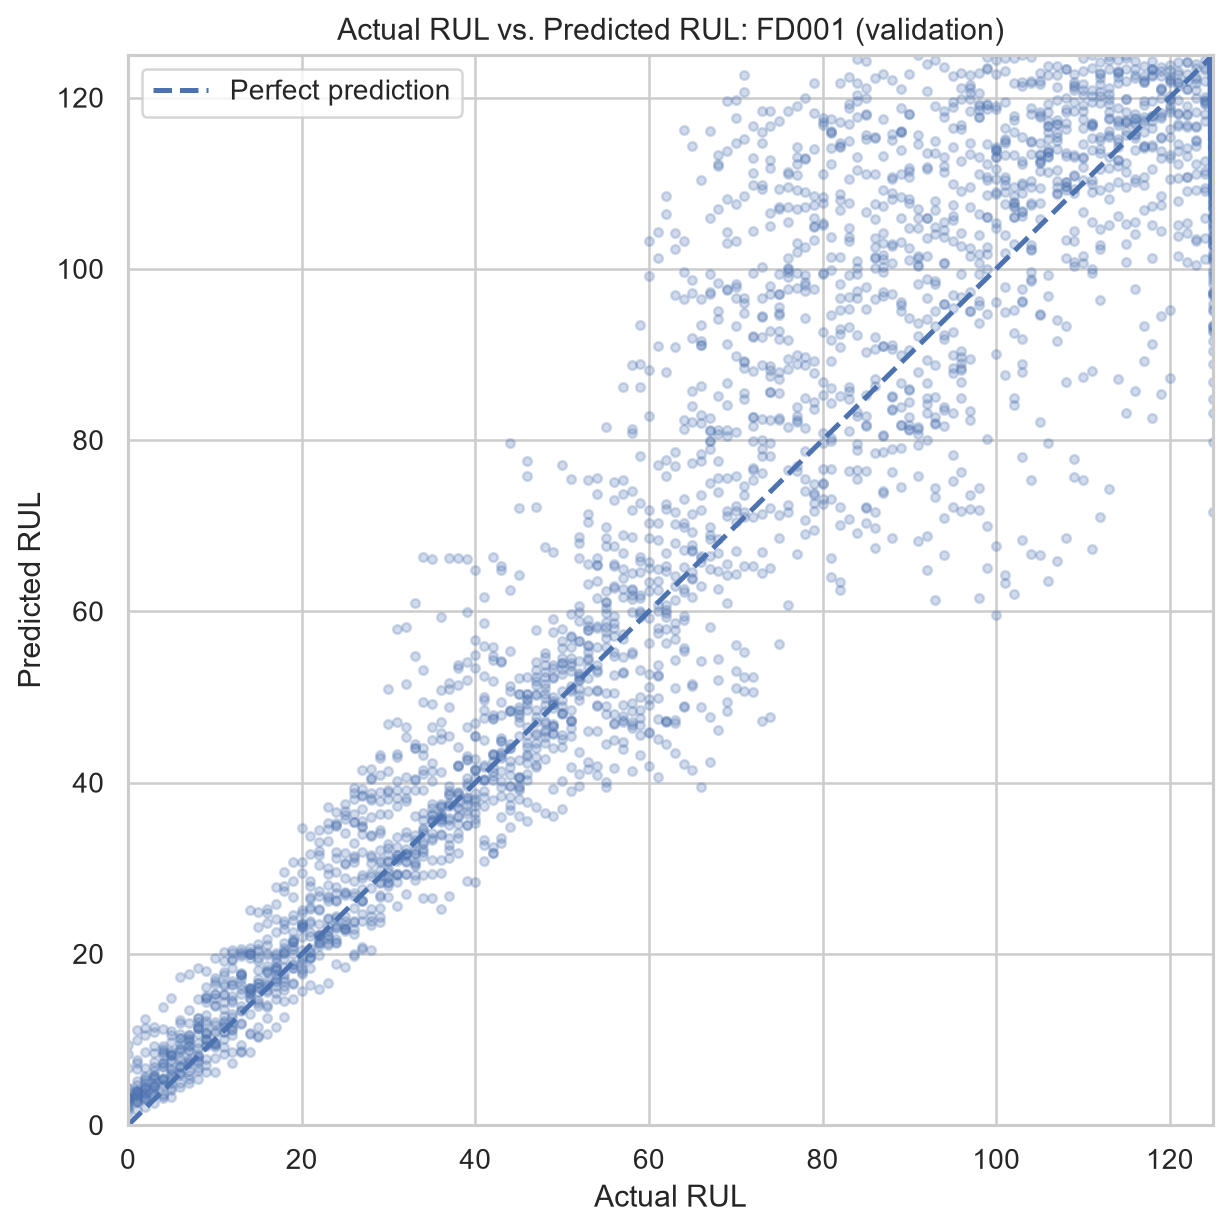


Procesando test de FD001 con bootstrap...
  RUL: MSE=232.10, RMSE=15.23, MAE=11.40, NASA=420.62
  IC 95% por bootstrap (B=500): MSE=[161.94, 302.59], RMSE=[12.73, 17.40], MAE=[9.30, 13.37], NASA=[266.46, 603.49]
  Tiempo de test: 0.36s


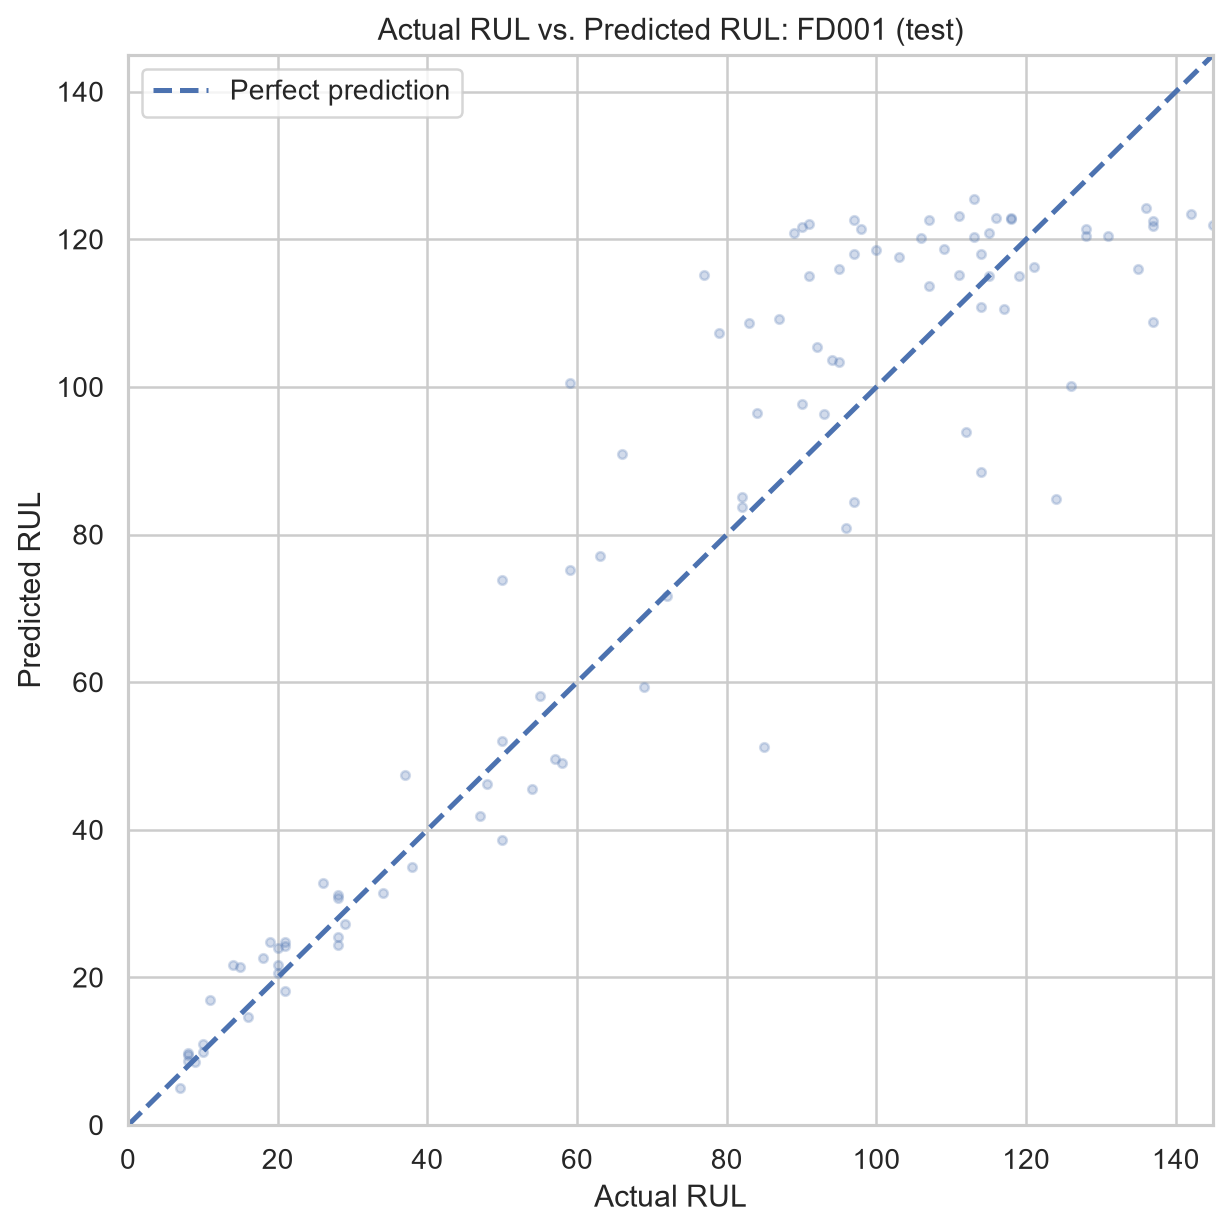

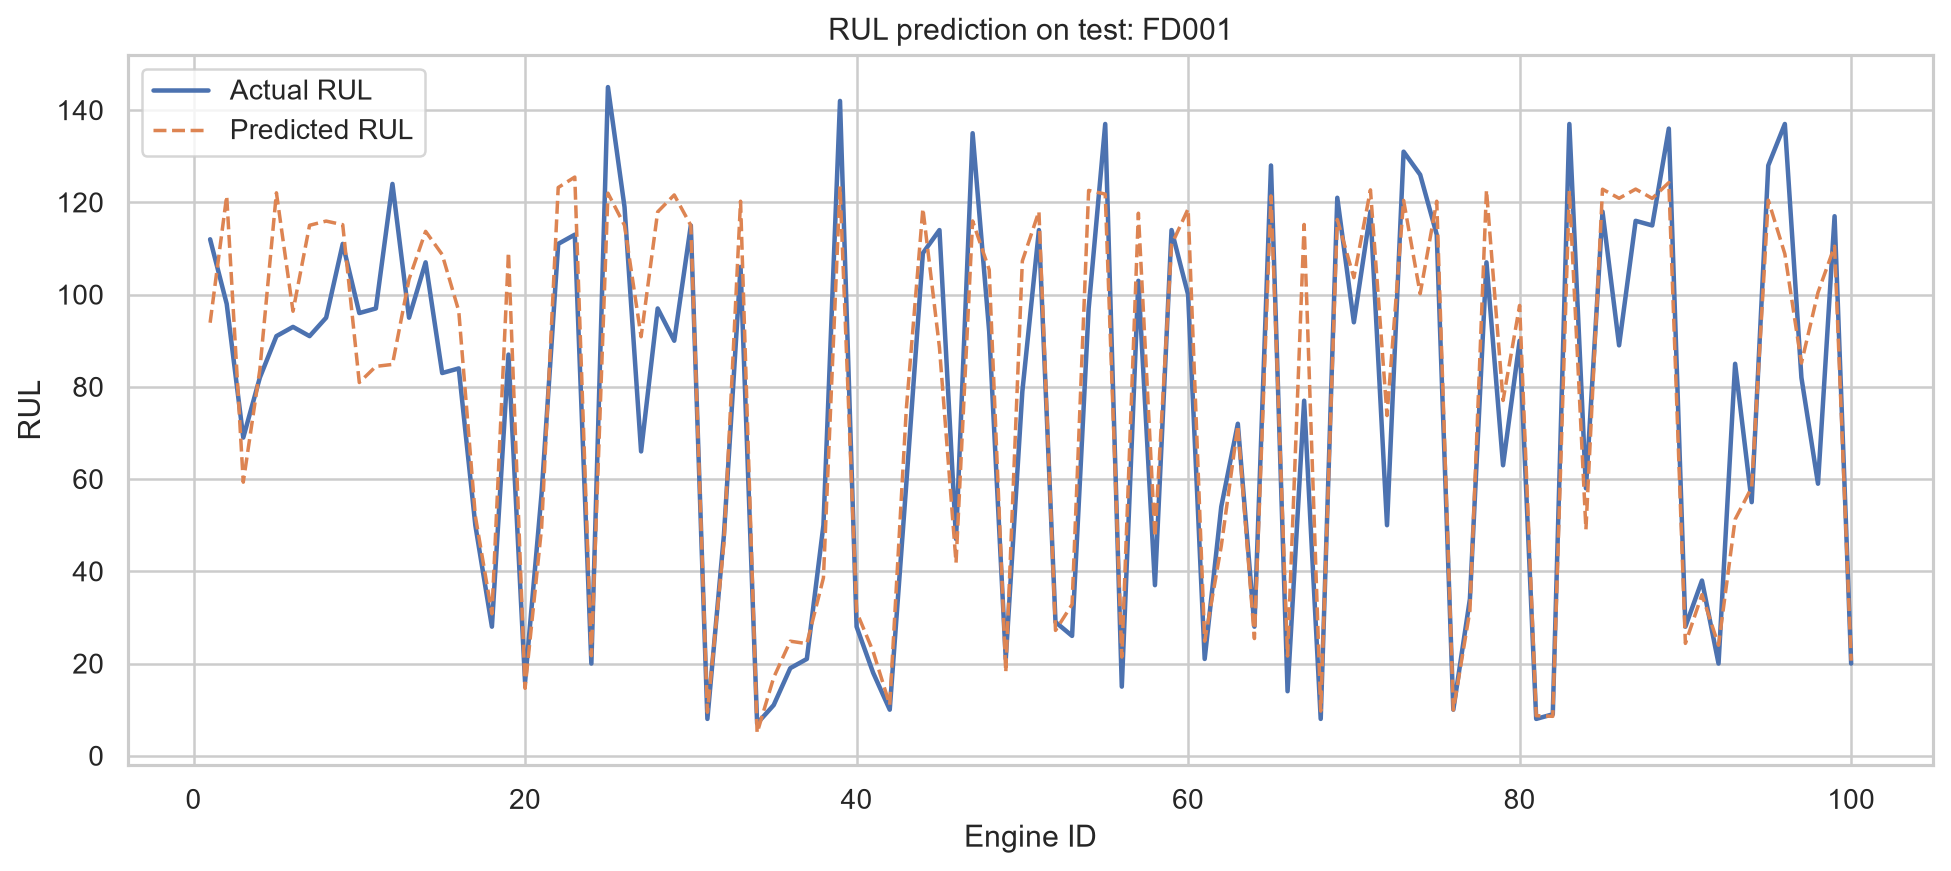

Modelo y preprocesadores guardados en: mopso_models\FD001_lightweight_mlp_mopso.pt


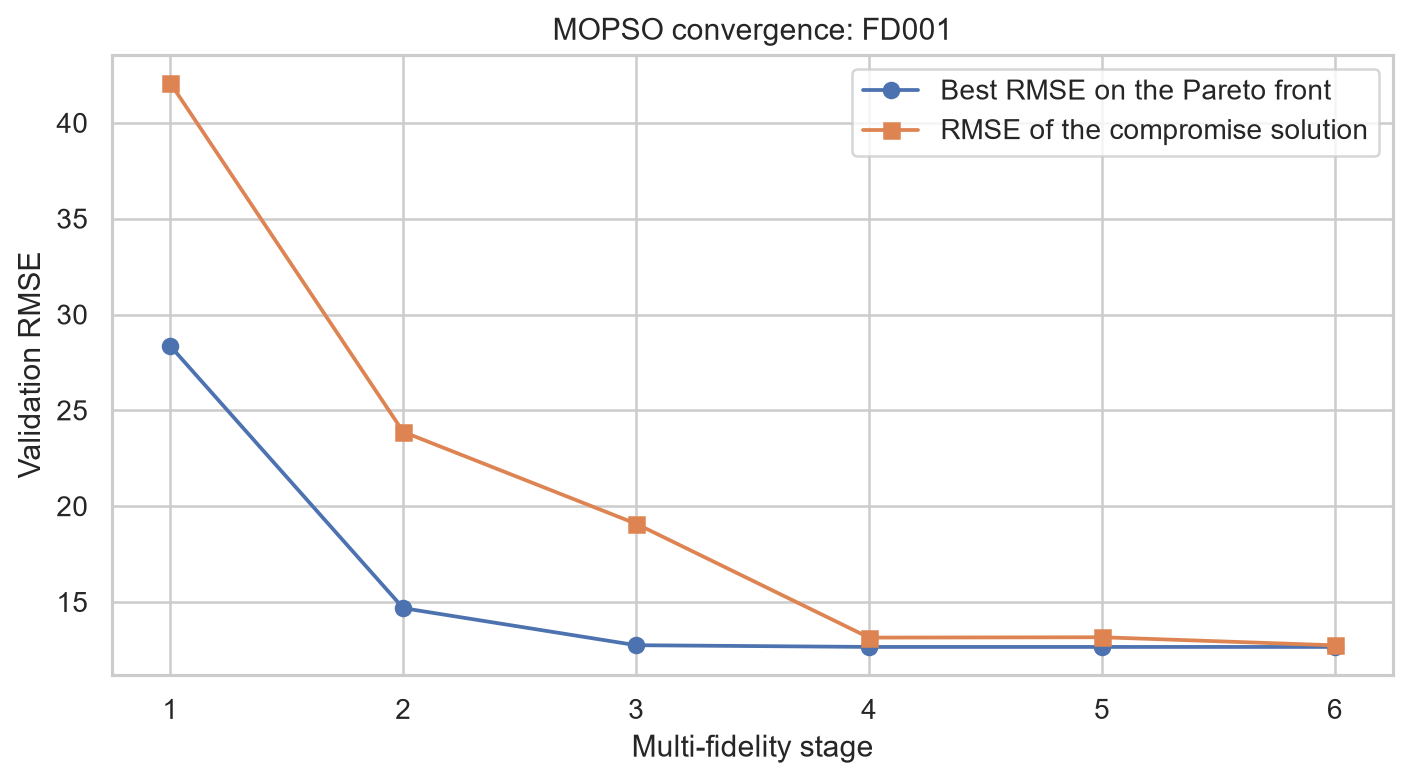

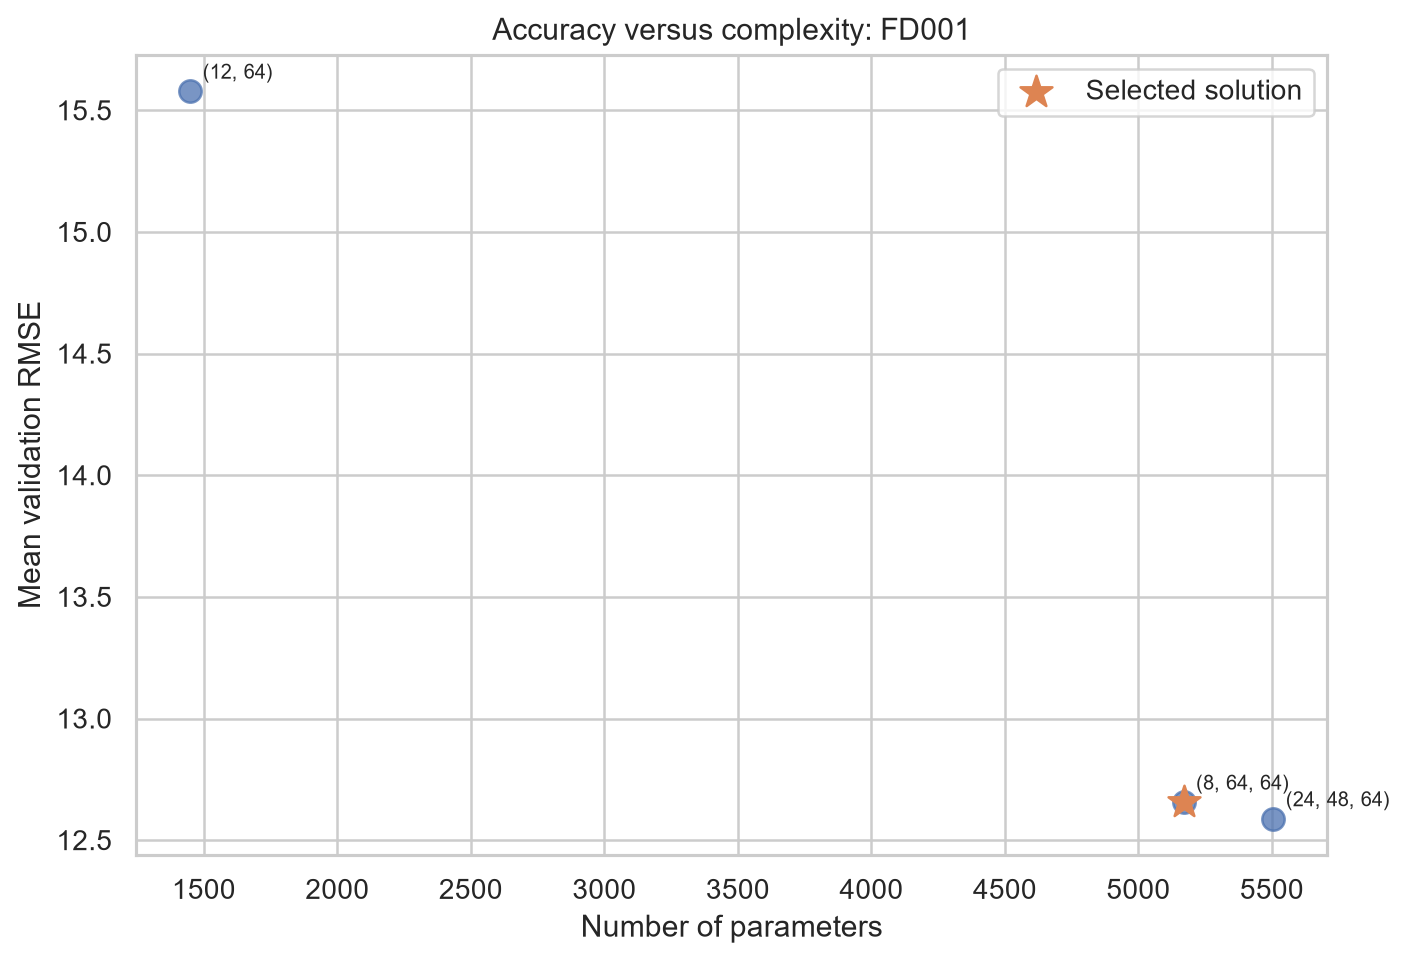


>> FD001 completado en 650.22s (10.84 min) <<

Ejecución total finalizada en 650.22s (10.84 min)
Resumen:
  Dataset                                      Architecture  Input variables  \
0   FD001  hidden=(8, 64, 64), activation=elu, dropout=0.05               45   

   Parameters  Mean validation RMSE  Std validation RMSE  \
0        5169             12.656204             0.179489   

   Validation MSE representative  Validation RMSE representative  \
0                     159.156448                       12.615722   

   Validation MAE representative    Test MSE  Test RMSE   Test MAE  \
0                       8.560789  232.099731   15.23482  11.400061   

    Test NASA                            Test MSE IC95  \
0  420.617371  (161.94299545288087, 302.5914146423339)   

                             Test RMSE IC95  \
0  (12.725682389381069, 17.395107737444985)   

                             Test MAE IC95  \
0  (9.302051186561584, 13.367479896545408)   

                            

,Dataset,Architecture,Input variables,Parameters,Mean validation RMSE,Std validation RMSE,Validation MSE representative,Validation RMSE representative,Validation MAE representative,Test MSE,Test RMSE,Test MAE,Test NASA,Test MSE IC95,Test RMSE IC95,Test MAE IC95,Test NASA IC95,Time_sec
0,FD001,"hidden=(8, 64, 64), activation=elu, dropout=0.05",45,5169,12.656204,0.179489,159.156448,12.615722,8.560789,232.099731,15.23482,11.400061,420.617371,"(161.94299545288087, 302.5914146423339)","(12.725682389381069, 17.395107737444985)","(9.302051186561584, 13.367479896545408)","(266.46451797485355, 603.4885452270506)",650.22


In [38]:
def main(datasets: Iterable[str] = DATASETS) -> pd.DataFrame:
    script_start = time.time()
    results: List[Dict[str, Any]] = []

    for dataset_name in datasets:
        result = process_dataset(dataset_name)
        if result:
            results.append(result)

    results_dataframe = pd.DataFrame(results)
    total_elapsed = time.time() - script_start

    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    results_dataframe.to_csv(
        RESULTS_DIR / "mopso_lightweight_summary.csv",
        index=False,
    )

    print(
        f"\n{'=' * 80}\nEjecución total finalizada en "
        f"{total_elapsed:.2f}s ({total_elapsed / 60:.2f} min)"
    )
    print("Resumen:")
    print(results_dataframe)

    return results_dataframe


main()

# Prunning

$min z (RMSE)$

s.t.

$number of arcs <= \alpha$
$0<\alpha<1 $
$\alpha >=0 $

Based on your notebook, I would implement pruning as a **second stage after MOPSO has selected the final architecture**. This keeps your current MOPSO cache/warm-start logic intact and makes the pruning experiment much easier to interpret.

One notation detail: your current `n_parameters` counts **weights + biases**, while “number of arcs” should count only the entries of the `nn.Linear.weight` matrices.

Here is a Markdown section ready to paste into the notebook.

## Poda de arcos mediante una restricción de esparsidad

Una vez seleccionada la arquitectura de la MLP mediante MOPSO, se introduce una segunda etapa de optimización destinada a reducir el número de conexiones activas de la red.

En esta etapa, la topología a nivel de capas permanece fija. La poda actúa sobre las conexiones individuales de las capas `Linear`, eliminando aquellos pesos que se consideran menos relevantes.

### Definición de arco

Para una MLP con dimensión de entrada (n_0), capas ocultas de tamaños

[
(n_1,n_2,\ldots,n_L)
]

y una salida escalar (n_{L+1}=1), el número de arcos de la red densa original es

[
A_0 =
\sum_{\ell=1}^{L+1}
n_{\ell-1}n_{\ell}.
]

Cada elemento de una matriz de pesos (W^{(\ell)}) representa un arco dirigido entre dos neuronas.

Los términos de sesgo (`bias`) no se consideran arcos. Por tanto, esta medida es diferente de `n_parameters`, utilizada anteriormente en el MOPSO, ya que `n_parameters` incluye tanto pesos como sesgos.

### Variables de poda

Para cada peso (w_{ij}^{(\ell)}) se define una variable binaria

[
m_{ij}^{(\ell)} \in {0,1},
]

donde

[
m_{ij}^{(\ell)} =
\begin{cases}
1, & \text{si el arco se conserva},\
0, & \text{si el arco se elimina}.
\end{cases}
]

La matriz efectiva de pesos de cada capa se define entonces como

[
\widetilde{W}^{(\ell)}
======================

W^{(\ell)} \odot M^{(\ell)},
]

donde (\odot) representa el producto elemento a elemento.

### Modelo de optimización

Sea (\alpha) la fracción máxima de arcos de la red original que pueden permanecer activos, con

[
0 < \alpha \leq 1.
]

Para un valor de (\alpha) fijado previamente, el problema de poda puede escribirse como

[
\min_{W,M} \quad
z =
RMSE_{\mathrm{val}}
\left(
y,
f(X;,W\odot M,b)
\right)
]

sujeto a

[
\sum_{\ell=1}^{L+1}
\sum_{i=1}^{n_{\ell-1}}
\sum_{j=1}^{n_{\ell}}
m_{ij}^{(\ell)}
\leq
\left\lfloor
\alpha A_0
\right\rfloor,
]

[
m_{ij}^{(\ell)}\in{0,1}.
]

De forma explícita, el objetivo utilizado es

[
RMSE_{\mathrm{val}}
===================

\sqrt{
\frac{1}{N_{\mathrm{val}}}
\sum_{k=1}^{N_{\mathrm{val}}}
\left(
y_k-\hat y_k
\right)^2
}.
]

Para mantener la misma definición empleada durante la búsqueda MOPSO, las predicciones de validación pueden limitarse al intervalo de RUL:

[
\hat y_k =
\operatorname{clip}
\left(
f(x_k),0,RUL_{\max}
\right),
\qquad
RUL_{\max}=125.
]

### Interpretación de (\alpha)

En esta formulación, (\alpha) representa la **fracción máxima de arcos conservados**, no el número absoluto de arcos.

Por ejemplo,

[
\alpha=0.70
]

significa que como máximo puede permanecer activo el (70%) de los arcos originales, por lo que al menos el (30%) debe ser eliminado.

Si

[
A_0=5000,
]

entonces

[
A_{\mathrm{activo}}
\leq
\lfloor0.70(5000)\rfloor
========================

3500.

]

La esparsidad obtenida puede expresarse como

[
S
=

1-
\frac{A_{\mathrm{activo}}}{A_0}.
]

Por tanto, idealmente,

[
S \geq 1-\alpha.
]

### Estrategia práctica de solución

La optimización conjunta de todos los pesos y todas las variables binarias (m_{ij}^{(\ell)}) constituye un problema combinatorio no convexo de gran dimensión.

Por esta razón, se utiliza una aproximación en dos etapas:

1. Entrenar y seleccionar primero la arquitectura densa mediante el MOPSO existente.
2. Ordenar globalmente los pesos de las capas `Linear` de acuerdo con su magnitud absoluta.
3. Conservar únicamente los

[
K=\lfloor\alpha A_0\rfloor
]

pesos de mayor magnitud.
4. Asignar máscara cero al resto de los pesos.
5. Mantener las máscaras fijas y realizar un proceso corto de *fine-tuning*.
6. Seleccionar el checkpoint con menor RMSE de validación.
7. Evaluar el conjunto de test solamente después de haber fijado tanto la arquitectura como el nivel de poda.

Esta estrategia corresponde a **global unstructured magnitude pruning**, porque la comparación de magnitudes se realiza globalmente entre todas las capas y se eliminan conexiones individuales.

### Relación con MOPSO

La búsqueda MOPSO actual determina

[
(\text{profundidad},
\text{anchuras},
\text{activación},
\text{dropout})
]

utilizando como objetivos el RMSE y el número total de parámetros.

La poda se ejecuta posteriormente sobre la solución seleccionada:

[
\text{MOPSO}
\longrightarrow
\text{MLP densa seleccionada}
\longrightarrow
\text{poda}
\longrightarrow
\text{fine-tuning}
\longrightarrow
\text{modelo final}.
]

Se evita introducir una variable binaria por cada arco dentro de la codificación del PSO, ya que esto aumentaría la dimensión de búsqueda desde unas pocas variables arquitectónicas hasta potencialmente miles de variables binarias y además interferiría con el mecanismo actual de caché y *warm start*.

### Selección de (\alpha)

Si (\alpha) se considera una variable de decisión y el único objetivo es minimizar el RMSE, la solución tendería naturalmente hacia

[
\alpha \rightarrow 1,
]

es decir, hacia una red sin poda.

Por ello, (\alpha) debe:

* fijarse como un presupuesto de complejidad; o
* evaluarse sobre un conjunto discreto de valores utilizando únicamente validación; o
* incorporarse como un segundo objetivo.

Una posible extensión multiobjetivo sería

[
\min
\left(
RMSE_{\mathrm{val}},
\frac{A_{\mathrm{activo}}}{A_0}
\right).
]

Esto permitiría obtener un nuevo frente de Pareto entre precisión predictiva y esparsidad.

### Codificación recomendada

I would **not** add one binary PSO dimension per arc. Your `SearchSpace` currently has only architecture-level variables:

```text
[depth, width1, width2, width3, activation, dropout]
```

Turning every weight into a PSO variable could suddenly produce thousands of dimensions. Instead, use PyTorch's pruning utilities on the final MLP. Add this import beside your current PyTorch imports:

```python
import torch.nn.utils.prune as prune
```

Then add these utilities after `count_mlp_parameters()`:

```python
def get_linear_layers(model: MLPRegressor) -> List[nn.Linear]:
    """Devuelve las capas que contienen arcos ponderados."""
    return [
        module
        for module in model.model.modules()
        if isinstance(module, nn.Linear)
    ]


def count_mlp_arcs(model: MLPRegressor) -> int:
    """Número de arcos de la MLP.

    Se cuentan únicamente pesos de capas Linear.
    Los bias no se consideran arcos.
    """
    return int(
        sum(
            layer.weight.numel()
            for layer in get_linear_layers(model)
        )
    )


def count_active_arcs(model: MLPRegressor) -> int:
    """Cuenta los arcos activos durante la poda."""
    active = 0

    for layer in get_linear_layers(model):
        if hasattr(layer, "weight_mask"):
            active += int(
                torch.count_nonzero(layer.weight_mask).item()
            )
        else:
            active += int(layer.weight.numel())

    return active


def apply_global_magnitude_pruning(
    model: MLPRegressor,
    alpha: float,
) -> Dict[str, int | float]:
    """Aplica poda global respetando A_active <= floor(alpha * A0).

    Parameters
    ----------
    alpha:
        Fracción máxima de arcos que se desea conservar.
        alpha=0.70 implica eliminar al menos el 30 %.
    """
    if not 0.0 < alpha <= 1.0:
        raise ValueError("alpha debe cumplir 0 < alpha <= 1.")

    layers = get_linear_layers(model)
    parameters_to_prune = [
        (layer, "weight")
        for layer in layers
    ]

    total_arcs = count_mlp_arcs(model)
    target_active = int(math.floor(alpha * total_arcs))
    target_pruned = total_arcs - target_active

    if target_pruned > 0:
        # Se usa un entero, en lugar de una fracción, para imponer
        # exactamente el presupuesto deseado de arcos.
        prune.global_unstructured(
            parameters_to_prune,
            pruning_method=prune.L1Unstructured,
            amount=target_pruned,
        )

    active_arcs = count_active_arcs(model)

    return {
        "alpha": float(alpha),
        "total_arcs": int(total_arcs),
        "active_arcs": int(active_arcs),
        "pruned_arcs": int(total_arcs - active_arcs),
        "sparsity": float(1.0 - active_arcs / total_arcs),
    }


def make_pruning_permanent(model: MLPRegressor) -> None:
    """Incorpora las máscaras a los pesos antes de guardar el modelo."""
    for layer in get_linear_layers(model):
        if hasattr(layer, "weight_orig"):
            prune.remove(layer, "weight")
```

The important part is that the masks need to remain active during fine-tuning. Otherwise AdamW would simply make the zeroed weights nonzero again.

You can reuse your existing `train_additional_epochs()` for that:

```python
PRUNING_FINE_TUNE_EPOCHS = 1_000
PRUNING_VALIDATION_INTERVAL = 25
PRUNING_EARLY_STOPPING_PATIENCE = 10
PRUNING_MIN_EPOCHS_BEFORE_STOP = 100


def prune_and_finetune(
    dense_model: MLPRegressor,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    alpha: float,
) -> Tuple[MLPRegressor, Dict[str, Any]]:
    """Poda una copia del modelo denso y realiza fine-tuning."""

    # Trabajar sobre una copia independiente de la solución MOPSO.
    model = MLPRegressor(
        input_size=dense_model.input_size,
        architecture=dense_model.architecture,
        learning_rate=dense_model.learning_rate,
        weight_decay=dense_model.weight_decay,
    )
    model.load_weights(dense_model.get_weights())

    pruning_info = apply_global_magnitude_pruning(
        model=model,
        alpha=alpha,
    )

    # Reconstruir AdamW después de crear weight_orig/weight_mask.
    model.optimizer = optim.AdamW(
        model.model.parameters(),
        lr=model.learning_rate,
        weight_decay=model.weight_decay,
    )

    # Evaluar inmediatamente después de podar.
    initial_predictions = model.predict_clipped(X_val)
    initial_metrics = regression_metrics(
        y_val,
        initial_predictions,
    )
    initial_weights = model.get_weights()

    # Fine-tuning manteniendo fija la máscara.
    state = train_additional_epochs(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        start_epoch=0,
        additional_epochs=PRUNING_FINE_TUNE_EPOCHS,
        validation_interval=PRUNING_VALIDATION_INTERVAL,
        previous_best_weights=initial_weights,
        previous_best_epoch=0,
        previous_best_metrics=initial_metrics,
        early_stopping_patience=PRUNING_EARLY_STOPPING_PATIENCE,
        minimum_epochs_before_stop=PRUNING_MIN_EPOCHS_BEFORE_STOP,
        minimum_delta_rmse=0.0,
        verbose=False,
    )

    # Recuperar el mejor checkpoint observado.
    model.load_weights(state.best_weights)

    final_predictions = model.predict_clipped(X_val)
    final_metrics = regression_metrics(
        y_val,
        final_predictions,
    )

    pruning_info.update(
        {
            "rmse_before_finetune": initial_metrics["rmse"],
            "rmse_after_finetune": final_metrics["rmse"],
            "mae_after_finetune": final_metrics["mae"],
            "nasa_after_finetune": nasa_score(
                y_val,
                final_predictions,
            ),
            "best_epoch": state.best_epoch,
        }
    )

    # Convierte weight_orig * weight_mask nuevamente en un weight normal.
    # Los elementos podados quedan exactamente en cero.
    make_pruning_permanent(model)

    return model, pruning_info
```

Then the integration into your existing `process_dataset()` is very small. Immediately after:

```python
final_model = build_model_from_final_selection(
    input_size=X_train.shape[1],
    final_selection=final_selection,
)
```

you can initially test one pruning budget:

```python
PRUNING_ALPHA = 0.70

final_model, pruning_results = prune_and_finetune(
    dense_model=final_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    alpha=PRUNING_ALPHA,
)

print("\nResultado de poda:")
print(
    f"  alpha={pruning_results['alpha']:.2f} | "
    f"arcos originales={pruning_results['total_arcs']} | "
    f"arcos activos={pruning_results['active_arcs']} | "
    f"esparsidad={100 * pruning_results['sparsity']:.1f}%"
)
print(
    f"  RMSE antes fine-tuning="
    f"{pruning_results['rmse_before_finetune']:.3f}"
)
print(
    f"  RMSE después fine-tuning="
    f"{pruning_results['rmse_after_finetune']:.3f}"
)
```

After that, your existing `evaluate_validation_model()` and `test_final_model()` can operate on the **pruned `final_model`** without major changes.

One methodological point I would preserve carefully: if you want to compare, for example, (\alpha\in{0.9,0.8,0.7,0.6,0.5}), choose among those values using **validation only** and then run `test_final_model()` once for the chosen pruning configuration, just as your notebook currently keeps the test set outside architecture selection.

Also, unstructured pruning gives you the exact **arc-level formulation** you described, but standard `nn.Linear` will still execute/store mostly as a dense matrix after `prune.remove`. So it demonstrates sparsity and removes connections, but it does **not automatically guarantee proportional inference-speed or file-size reduction**. If your eventual objective is physical model compression/latency rather than number of active arcs, a later structured-neuron pruning formulation would be the next step.
